<a href="https://colab.research.google.com/github/airzao/uwine-tcc-uvv/blob/main/ARIDALTON_JUNIOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<html>
  <body>
    <header></header>
        <CENTER>
          <img src="https://professor.uvv.br/Content/img/logo-uvv.png" alt="UVV-LOGO" style = width="100px"; height="100px">
        </CENTER>
        <CENTER><b>DATA SCIENCE PROJECT</b></CENTER><br/>
        <CENTER><b>WORKFLOW PARTE 1 DO PROJETO</b></CENTER><br/>

NOME COMPLETO: ARIDALTON DE SOUSA MOREIRA JÚNIOR

LINK PARA SEU PRÓPRIO COLAB: [Aqui](https://colab.research.google.com/drive/1kzjVqMkvVohJ7AUXuiVV7pH5r3WE8PVS?usp=sharing)

LINK PARA SEU PRÓPRIO GITHUB: [Aqui](https://github.com/airzao/uwine-tcc-uvv)

LINK PARA SEU VÍDEO NO YOUTUBE: [Aqui](https://youtu.be/2UGDNatjmSE)

<center>

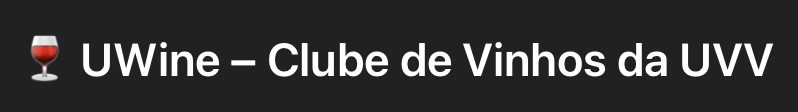

<center>

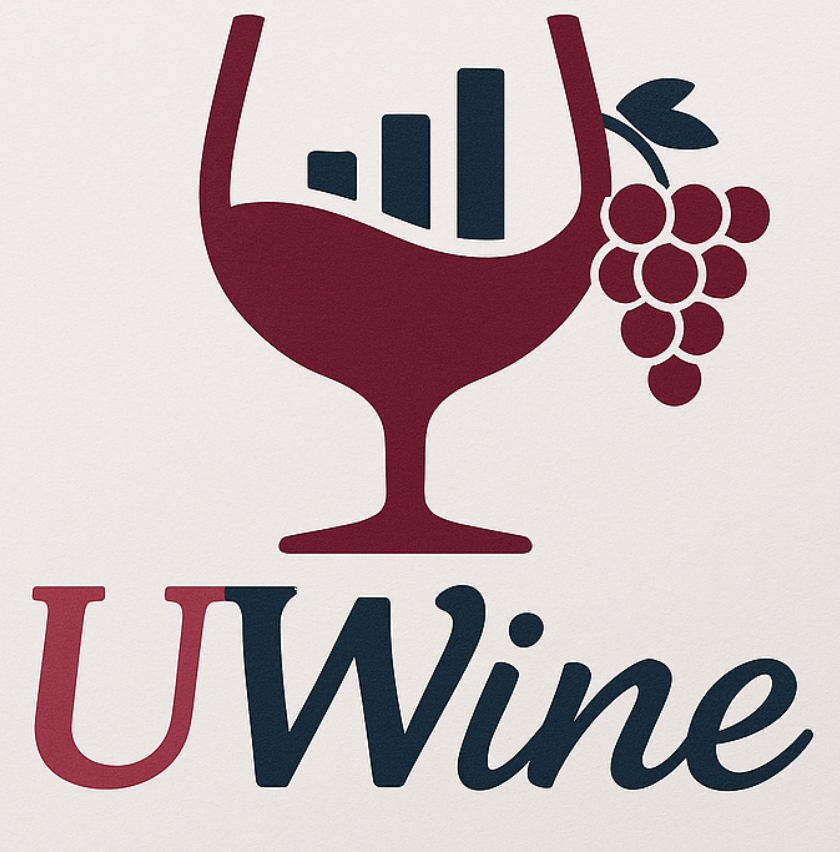

# **Cenário Fictício**:

Prezados(as) alunos(as),

É com entusiasmo que apresento a proposta do **Projeto de Conclusão de Curso (TCC)** para os estudantes do curso de Ciência de Dados da Universidade Vila Velha: o UWine – Clube de Vinhos da UVV.

A proposta do projeto consiste na análise de um Clube de Vinhos universitário fictício, com base em dados simulados, que será totalmente orientado por técnicas e práticas de Ciência de Dados.

Sendo assim, você foi designado como **Consultor em Ciência de Dados** ( ***Data Science Consultant*** ) para fazer uma análise completa dos dados dos clientes a partir de um conjunto de dados (Amostra) com mais de 1 milhão de notas fiscais (~ 350 Megabytes). Além disso, há uma entrada diária de aproximadamente umas 5000 novas notas fiscais no sistema.

O objetivo é permitir que cada consultor(a) percorra foco analíticos diferentes dentro do mesmo ecossistema de dados, aplicando modelos de machine learning supervisionado ou não supervisionado, análise preditiva, dashboards interativos, entre outros.

Para garantir organização, profundidade técnica e coerência metodológica no desenvolvimento do ***Projeto UWine***, adotaremos um workflow composto por cinco etapas principais, alinhadas às boas práticas da Ciência de Dados. Cada etapa representa um marco do processo analítico, permitindo que cada analista avance de forma estruturada do entendimento inicial dos dados até a entrega final dos insights.

# BIBLIOTECAS E FUNÇÕES E CÓDIGOS

In [38]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import bootstrap
from IPython.display import display

sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_colwidth", None)

ALVO = "TOTAL (R$)"
ESTRATO = "TIPO DA CONTA"
ENTRADA_DIARIA = 5000

In [39]:
def carregar_tabela(caminho):
    """
    Carrega o CSV do projeto UWine corrigindo as linhas gravadas entre aspas.

    No arquivo, toda linha cuja OPINIÃO DO CLIENTE tem vírgula foi gravada
    inteira entre aspas. Lida direto com pd.read_csv, essa linha vira um único
    campo e as outras 22 colunas ficam vazias (cerca de 27% das linhas). A
    função grava uma cópia corrigida em /tmp, linha a linha (sem carregar o
    arquivo inteiro na memória), e lê essa cópia.

    Parâmetros
    ----------
    caminho : str
        Caminho do CSV. No Colab, com o arquivo na pasta de arquivos, basta o
        nome: "table4.csv".

    Retorna
    -------
    pandas.DataFrame
        Tabela com a primeira coluna do arquivo como índice.
    """
    if not os.path.exists(caminho):
        raise FileNotFoundError(f"{caminho} não encontrado. Confira o painel Arquivos do Colab.")

    destino = "/tmp/table_corrigida.csv"
    with open(caminho, encoding="utf-8") as origem, open(destino, "w", encoding="utf-8") as saida:
        for linha in origem:
            linha = linha.rstrip("\r\n")
            if len(linha) > 1 and linha[0] == '"' and linha[-1] == '"':
                linha = linha[1:-1].replace('""', '"')
            saida.write(linha + "\n")
    return pd.read_csv(destino, index_col=0)

In [40]:
# load do seu TABLE 4 aqui: Numero 4
table4 = carregar_tabela("table4.csv")

In [41]:
table4.head()

,NOTA FISCAL,REGIÃO,SEXO,ESTADO CIVIL,DEPENDENTES,RENDA BRUTO (R$),OPINIÃO DO CLIENTE,NOTA DE SATISFAÇÃO (%),MEAN: alcohol,MEAN: malic_acid,...,MEAN: total_phenols,MEAN: flavanoids,MEAN: nonflavanoid_phenols,MEAN: proanthocyanins,MEAN: color_intensity,MEAN: hue,MEAN: od280/od315_of_diluted_wines,MEAN: proline,TIPO DA CONTA,TOTAL (R$)
0,7336788,SUDESTE,MASCULINO,CASADO,1,3322.66,Nada digno de nota com a UVVine,68.68,12.834441,3.041814,...,3.128712,2.433995,0.323600,1.760394,5.104883,1.045760,4.782138,729.967415,ESSENTIAL,600.07
1,8688607,SUDESTE,MASCULINO,SOLTEIRO,0,3307.41,"Serviço eficiente, recomendo o clube: UVVine",68.68,13.183401,4.133115,...,1.485828,-0.266383,0.301228,1.509933,7.291732,1.063899,3.033748,604.904221,ESSENTIAL,200.43
2,2088810,SUDESTE,FEMININO,CASADO,1,4927.84,"Serviço eficiente, recomendo o clube: UVVine",68.68,13.620679,3.432490,...,2.539629,1.822710,0.368851,1.169771,6.031266,0.748121,2.878856,788.998353,ESSENTIAL,494.77
3,1076760,SUDESTE,MASCULINO,CASADO,2,7659.02,"Serviço eficiente, recomendo o clube: UVVine",68.68,12.820626,3.500462,...,2.598476,1.376106,0.439744,1.459007,3.821879,0.953541,1.091151,990.193879,VIP,1380.61
4,7511751,CENTRO-OESTE,MASCULINO,SOLTEIRO,2,24139.61,Nada digno de nota com a UVVine,68.68,13.914954,1.613307,...,2.646282,1.854863,0.236351,2.008337,4.112468,0.945904,3.457520,779.447597,PRIME,3381.54


In [42]:
table4.shape

(1120000, 23)

In [43]:
def conferir_carga(df):
    """
    Confere a carga da tabela antes das análises.

    Mostra a quantidade de notas fiscais, valores ausentes, números de nota
    fiscal repetidos, as colunas de texto (uma coluna numérica que aparece
    aqui foi lida errado) e o peso de cada tipo de conta.

    Parâmetros
    ----------
    df : pandas.DataFrame
        Tabela carregada.
    """
    print(f"{df.shape[0]} notas fiscais e {df.shape[1]} colunas")
    print(f"Valores ausentes: {int(df.isna().sum().sum())}")
    print(f"Números de NOTA FISCAL repetidos: {int(df['NOTA FISCAL'].duplicated().sum())}")
    print(f"Colunas de texto: {df.select_dtypes(exclude='number').columns.tolist()}")
    display(df[ESTRATO].value_counts(normalize=True).mul(100).round(2).rename("Peso (%)"))


conferir_carga(table4)

1120000 notas fiscais e 23 colunas
Valores ausentes: 0
Números de NOTA FISCAL repetidos: 0
Colunas de texto: ['REGIÃO', 'SEXO', 'ESTADO CIVIL', 'OPINIÃO DO CLIENTE', 'TIPO DA CONTA']


,Peso (%)
TIPO DA CONTA,
ESSENTIAL,63.99
VIP,21.13
PRIME,14.89


In [44]:
def optimal_stratified_sample_size(
    df,
    value_column,
    strata_column,
    n_min=100,
    n_max=50000,
    step=100,
    stabilization_threshold=0.01,
    consecutive_points=3,
    plot=True
):
    """
    Estimate the optimal sample size for an infinite stratified population
    using Neyman allocation and consecutive marginal stabilization of the
    stratified standard error.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset.

    value_column : str
        Numerical target variable used to estimate the mean.

    strata_column : str
        Categorical stratification variable.

    n_min : int, default=100
        Minimum total sample size evaluated.

    n_max : int, default=50000
        Maximum total sample size evaluated.

    step : int, default=100
        Increment between consecutive sample sizes.

    stabilization_threshold : float, default=0.01
        Maximum relative reduction accepted for standard error stabilization.
        Example: 0.01 means 1%.

    consecutive_points : int, default=3
        Number of consecutive marginal reductions that must remain below
        the stabilization threshold.

    plot : bool, default=True
        If True, plot the standard error stabilization curve.

    Returns
    -------
    summary : pandas.DataFrame
        Sample allocation per stratum.

    results : dict
        Dictionary containing:
        - optimal_n
        - optimal_standard_error
        - sample_sizes
        - standard_error_curve
        - marginal_reduction
        - stabilization_threshold
        - consecutive_points
        - strata_statistics
    """

    # Keep only the required columns and remove missing values
    data = df[[value_column, strata_column]].dropna().copy()

    # Convert the target variable to numeric
    data[value_column] = pd.to_numeric(data[value_column], errors="coerce")
    data = data.dropna()

    if data.empty:
        raise ValueError("The dataset is empty after removing missing or invalid values.")

    # Estimate stratum weights
    weights = (
        data[strata_column]
        .value_counts(normalize=True)
        .sort_index()
    )

    # Estimate stratum standard deviations
    stds = (
        data.groupby(strata_column)[value_column]
        .std()
        .sort_index()
    )

    # Align both series
    stds = stds.loc[weights.index]

    strata = weights.index.values
    Wh = weights.values
    Sh = stds.values

    if np.any(np.isnan(Sh)):
        raise ValueError(
            "At least one stratum has insufficient observations "
            "to calculate standard deviation."
        )

    if np.any(Sh == 0):
        print(
            "Warning: At least one stratum has zero standard deviation. "
            "Neyman allocation may assign a very small sample to this stratum."
        )

    # Neyman allocation weights
    neyman_weights = Wh * Sh

    if neyman_weights.sum() == 0:
        raise ValueError(
            "Neyman weights are zero. Check the variability of the target variable."
        )

    sample_sizes = np.arange(n_min, n_max + step, step)

    standard_errors = []
    allocations = []

    for n in sample_sizes:

        nh = n * neyman_weights / neyman_weights.sum()

        se = np.sqrt(
            np.sum(
                (Wh ** 2) * (Sh ** 2) / nh
            )
        )

        standard_errors.append(se)
        allocations.append(nh)

    standard_errors = np.array(standard_errors)
    allocations = np.array(allocations)

    # Marginal relative reduction of the standard error
    marginal_reduction = (
        np.abs(np.diff(standard_errors)) / standard_errors[:-1]
    )

    stable_sequence_index = None

    for i in range(0, len(marginal_reduction) - consecutive_points + 1):

        window = marginal_reduction[i:i + consecutive_points]

        if np.all(window < stabilization_threshold):
            stable_sequence_index = i
            break

    if stable_sequence_index is None:
        raise ValueError(
            "No consecutive stabilization point found within the evaluated interval. "
            "Try increasing n_max, increasing step, or using a larger threshold."
        )

    optimal_index = stable_sequence_index + consecutive_points

    optimal_n = sample_sizes[optimal_index]
    optimal_se = standard_errors[optimal_index]
    optimal_allocation = allocations[optimal_index]

    summary = pd.DataFrame({
        "Stratum": strata,
        "Population Weight (Wh)": Wh,
        "Std. Deviation (Sh)": Sh,
        "Neyman Weight (Wh x Sh)": neyman_weights,
        "Allocated Sample (nh)": np.round(optimal_allocation).astype(int)
    })

    summary["Allocated Sample (%)"] = (
        summary["Allocated Sample (nh)"] /
        summary["Allocated Sample (nh)"].sum()
    )

    strata_statistics = pd.DataFrame({
        "Stratum": strata,
        "Wh": Wh,
        "Sh": Sh,
        "Wh_x_Sh": neyman_weights
    })

    if plot:

        plt.figure(figsize=(11, 6))

        plt.plot(
            sample_sizes,
            standard_errors,
            linewidth=3,
            label="Stratified standard error"
        )

        plt.scatter(
            optimal_n,
            optimal_se,
            s=120,
            label="Optimal sample size"
        )

        plt.axvline(
            optimal_n,
            linestyle="--"
        )

        plt.text(
            optimal_n,
            optimal_se,
            f"  n = {optimal_n}\n  SE = {optimal_se:.4f}",
            verticalalignment="bottom"
        )

        plt.xlabel("Total Sample Size (n)")
        plt.ylabel("Stratified Standard Error")
        plt.title("Consecutive Marginal Stabilization of the Standard Error")
        plt.grid(True)
        plt.legend()
        plt.show()

    results = {
        "optimal_n": int(optimal_n),
        "optimal_standard_error": float(optimal_se),
        "sample_sizes": sample_sizes,
        "standard_error_curve": standard_errors,
        "marginal_reduction": marginal_reduction,
        "stabilization_threshold": stabilization_threshold,
        "consecutive_points": consecutive_points,
        "strata_statistics": strata_statistics
    }

    return summary, results

In [45]:
def optimal_sample_size(
    df,
    value_column,
    strata_column=None,
    stratum=None,
    n_min=100,
    n_max=50000,
    step=100,
    stabilization_threshold=0.01,
    consecutive_points=3,
    repetitions=30,
    random_state=42,
    plot=True,
    title=None
):
    """
    Estima o tamanho ideal da amostra de forma empírica (população infinita).

    Para cada repetição a população é embaralhada e os n primeiros valores
    formam a amostra de tamanho n, de modo que as amostras são aninhadas e o
    erro-padrão de todos os tamanhos sai de somas acumuladas. A curva final é a
    média das repetições. O tamanho ideal é o primeiro ponto depois de
    `consecutive_points` reduções marginais seguidas abaixo do limiar.

    Parâmetros
    ----------
    df : pandas.DataFrame
        Base completa.
    value_column : str
        Variável alvo (ex.: TOTAL (R$)).
    strata_column : str, opcional
        Coluna que define os grupos. Se vazio usa a base inteira (GERAL).
    stratum : str, opcional
        Grupo analisado (ex.: VIP). Só vale junto com `strata_column`.
    n_min, n_max, step : int
        Faixa e passo dos tamanhos avaliados.
    stabilization_threshold : float
        Redução relativa máxima aceita entre dois pontos (0.01 = 1%).
    consecutive_points : int
        Quantidade de reduções seguidas abaixo do limiar.
    repetitions : int
        Número de embaralhamentos usados para suavizar a curva.
    random_state : int
        Semente do gerador aleatório.
    plot : bool
        Se True desenha o gráfico do erro-padrão.
    title : str, opcional
        Nome do grupo mostrado no título do gráfico.

    Retorna
    -------
    dict
        optimal_n, optimal_standard_error, sample_sizes, standard_error_curve,
        marginal_reduction, population_size.
    """
    dados = df
    if strata_column is not None and stratum is not None:
        dados = df[df[strata_column] == stratum]

    valores = pd.to_numeric(dados[value_column], errors="coerce").dropna()
    valores = valores.to_numpy(dtype=float)
    populacao = len(valores)

    if populacao < n_min + step:
        raise ValueError("Poucas observações para avaliar a curva do erro-padrão.")

    if n_max > populacao:
        print(f"n_max reduzido de {n_max} para {populacao} (tamanho do grupo).")
        n_max = populacao

    tamanhos = np.arange(n_min, n_max + 1, step)
    rng = np.random.default_rng(random_state)
    erros = np.zeros((repetitions, len(tamanhos)))

    for r in range(repetitions):
        ordem = valores[rng.permutation(populacao)]
        ordem = ordem - ordem.mean()
        soma = np.cumsum(ordem)[tamanhos - 1]
        soma_quad = np.cumsum(ordem ** 2)[tamanhos - 1]
        variancia = (soma_quad - soma ** 2 / tamanhos) / (tamanhos - 1)
        erros[r] = np.sqrt(variancia / tamanhos)

    curva = erros.mean(axis=0)
    reducao = np.abs(np.diff(curva)) / curva[:-1]

    inicio = None
    for i in range(len(reducao) - consecutive_points + 1):
        if np.all(reducao[i:i + consecutive_points] < stabilization_threshold):
            inicio = i
            break

    if inicio is None:
        raise ValueError(
            "Nenhum ponto de estabilização encontrado. Aumente n_max, "
            "o passo ou o limiar."
        )

    indice = inicio + consecutive_points
    n_otimo = int(tamanhos[indice])
    se_otimo = float(curva[indice])

    if plot:
        nome = title if title else "GERAL"
        plt.figure(figsize=(11, 6))
        plt.plot(tamanhos, curva, linewidth=2.5, label="Erro-padrão médio")
        plt.scatter(n_otimo, se_otimo, s=110, color="red", zorder=3,
                    label="Tamanho ideal")
        plt.axvline(n_otimo, linestyle="--", color="red")
        plt.text(n_otimo, se_otimo, f"  n = {n_otimo}\n  SE = R$ {se_otimo:.2f}",
                 verticalalignment="bottom")
        plt.xlabel("Tamanho da amostra (n)")
        plt.ylabel("Erro-padrão da média (R$)")
        plt.title(f"Estabilização do erro-padrão: {nome}")
        plt.legend()
        plt.show()

    return {
        "optimal_n": n_otimo,
        "optimal_standard_error": se_otimo,
        "sample_sizes": tamanhos,
        "standard_error_curve": curva,
        "marginal_reduction": reducao,
        "population_size": populacao,
    }

In [46]:
def tamanho_ideal_por_grupo(df, value_column=ALVO, strata_column=ESTRATO, **parametros):
    """
    Aplica `optimal_sample_size` em cada grupo da coluna de estratos e na base inteira.

    Parâmetros
    ----------
    df : pandas.DataFrame
        Base completa.
    value_column : str
        Variável alvo.
    strata_column : str
        Coluna com os grupos (TIPO DA CONTA).
    **parametros
        Repassados para `optimal_sample_size` (n_min, n_max, step, etc.).

    Retorna
    -------
    tabela : pandas.DataFrame
        Uma linha por grupo com peso, n ideal e erro-padrão.
    resultados : dict
        Resultado completo de cada grupo (curvas incluídas).
    """
    pesos = df[strata_column].value_counts(normalize=True).sort_index()
    linhas = []
    resultados = {}

    for grupo in list(pesos.index) + ["GERAL"]:
        if grupo == "GERAL":
            res = optimal_sample_size(df, value_column, title="GERAL", **parametros)
            peso = 1.0
        else:
            res = optimal_sample_size(df, value_column, strata_column, grupo,
                                      title=grupo, **parametros)
            peso = float(pesos[grupo])

        resultados[grupo] = res
        linhas.append({
            "Grupo": grupo,
            "Peso na população": peso,
            "n ideal (no grupo)": res["optimal_n"],
            "SE no ponto (R$)": res["optimal_standard_error"],
            "n total equivalente": int(round(res["optimal_n"] / peso)),
        })

    return pd.DataFrame(linhas), resultados

In [47]:
def bootstrap_media(valores, n, nivel=0.95, repeticoes=2000, semente=42):
    """
    Faz a análise bootstrap da média de uma amostra de tamanho n.

    Sorteia n valores sem reposição e reamostra esses valores com reposição
    para obter o intervalo de confiança e o erro-padrão da média.

    Parâmetros
    ----------
    valores : array-like
        Valores da população (ou do grupo) de onde a amostra é sorteada.
    n : int
        Tamanho da amostra.
    nivel : float
        Nível de confiança do intervalo.
    repeticoes : int
        Número de reamostragens bootstrap.
    semente : int
        Semente aleatória.

    Retorna
    -------
    dict
        média, limites do intervalo, erro-padrão bootstrap, erro-padrão teórico
        (desvio/raiz de n) e a distribuição bootstrap.
    """
    rng = np.random.default_rng(semente)
    valores = np.asarray(valores, dtype=float)
    amostra = rng.choice(valores, size=n, replace=False)

    res = bootstrap((amostra,), np.mean, confidence_level=nivel,
                    n_resamples=repeticoes, method="percentile", random_state=rng)

    return {
        "n": n,
        "Média (R$)": float(amostra.mean()),
        "IC inferior (R$)": float(res.confidence_interval.low),
        "IC superior (R$)": float(res.confidence_interval.high),
        "Erro-padrão bootstrap (R$)": float(res.standard_error),
        "Erro-padrão teórico (R$)": float(amostra.std(ddof=1) / np.sqrt(n)),
        "distribuicao": res.bootstrap_distribution,
    }



def grafico_bootstrap_medias(resultados, titulo="Distribuição bootstrap da média do TOTAL (R$)"):
    """
    Desenha a distribuição bootstrap da média de cada grupo com o intervalo de confiança.

    Parâmetros
    ----------
    resultados : dict
        Grupo -> retorno de `bootstrap_media`.
    titulo : str
        Título geral da figura.
    """
    fig, eixos = plt.subplots(1, len(resultados), figsize=(4.5 * len(resultados), 4))

    for eixo, (grupo, res) in zip(np.atleast_1d(eixos), resultados.items()):
        sns.histplot(res["distribuicao"], bins=30, kde=True, stat="density", ax=eixo)
        eixo.axvline(res["IC inferior (R$)"], color="red", linestyle="--")
        eixo.axvline(res["IC superior (R$)"], color="red", linestyle="--")
        eixo.axvline(res["Média (R$)"], color="black")
        eixo.set_title(f"{grupo}\nIC 95%: R\\$ {res['IC inferior (R$)']:.2f} a R\\$ {res['IC superior (R$)']:.2f}")
        eixo.set_xlabel("Média (R$)")

    fig.suptitle(titulo)
    plt.tight_layout()
    plt.show()


def sensibilidade_limiar(df, limiares=(0.02, 0.01, 0.005), value_column=ALVO,
                         strata_column=ESTRATO, n_max=50000, step=100):
    """
    Mostra como o tamanho ideal de Neyman muda com o limiar de estabilização.

    Usa a função optimal_stratified_sample_size, sem gráfico, para cada limiar.

    Parâmetros
    ----------
    df : pandas.DataFrame
        Base completa.
    limiares : tuple of float
        Limiares testados (0.01 = 1%).
    value_column, strata_column : str
        Variável alvo e coluna dos estratos.
    n_max, step : int
        Faixa e passo dos tamanhos avaliados.

    Retorna
    -------
    pandas.DataFrame
        Limiar (%), n ideal e erro-padrão estratificado.
    """
    linhas = []
    for limiar in limiares:
        _, res = optimal_stratified_sample_size(
            df, value_column, strata_column, n_max=n_max, step=step,
            stabilization_threshold=limiar, plot=False
        )
        linhas.append({
            "Limiar (%)": 100 * limiar,
            "n ideal": res["optimal_n"],
            "Erro-padrão estratificado (R$)": res["optimal_standard_error"],
        })
    return pd.DataFrame(linhas)

In [48]:
def grafico_neyman(resultado):
    """
    Desenha a curva de estabilização do erro-padrão estratificado (Neyman) em português.

    Usa os valores calculados por optimal_stratified_sample_size, sem
    recalcular nada: só troca o gráfico original, que tem legendas em inglês.

    Parâmetros
    ----------
    resultado : dict
        Segundo retorno de optimal_stratified_sample_size.
    """
    n_otimo = resultado["optimal_n"]
    se_otimo = resultado["optimal_standard_error"]

    plt.figure(figsize=(11, 6))
    plt.plot(resultado["sample_sizes"], resultado["standard_error_curve"], linewidth=2.5,
             label="Erro-padrão estratificado")
    plt.scatter(n_otimo, se_otimo, s=110, color="red", zorder=3, label="Tamanho ideal")
    plt.axvline(n_otimo, linestyle="--", color="red")
    plt.text(n_otimo, se_otimo, f"  n = {n_otimo}\n  SE = {se_otimo:.2f} reais",
             verticalalignment="bottom")
    plt.xlabel("Tamanho total da amostra (n)")
    plt.ylabel("Erro-padrão estratificado (reais)")
    plt.title("Estabilização do erro-padrão: alocação de Neyman")
    plt.legend()
    plt.show()

def AtividadeA1_1(
    df=None,
    value_column=ALVO,
    strata_column=ESTRATO,
    n_min=100,
    n_max=50000,
    step=100,
    limiar=0.01,
    pontos_consecutivos=3,
    repeticoes=30,
    semente=42,
    criterio="bruto",
    detalhado=True
):
    """
    HELP:
    Atividade A1.1: determina o tamanho ideal da amostra.

    Gera os 4 gráficos do erro-padrão médio (ESSENTIAL, PRIME, VIP e GERAL)
    com o procedimento empírico prático (optimal_sample_size) e o gráfico da
    alocação de Neyman (optimal_stratified_sample_size), 5 gráficos no total.
    O tamanho ideal é o maior entre os tamanhos encontrados. Em seguida mostra
    a alocação de Neyman por estrato, o ganho da estratificação e a análise
    bootstrap (intervalo de confiança e erro-padrão) no tamanho ideal.

    Parâmetros
    ----------
    df : pandas.DataFrame, opcional
        Base completa. Se vazio usa a variável global table4.
    value_column, strata_column : str
        Variável alvo e coluna dos estratos.
    n_min, n_max, step : int
        Faixa e passo dos tamanhos avaliados.
    limiar : float
        Redução relativa máxima para considerar o erro-padrão estável.
    pontos_consecutivos : int
        Quantos pontos seguidos precisam ficar abaixo do limiar.
    repeticoes : int
        Repetições do procedimento prático.
    semente : int
        Semente aleatória.
    criterio : {"bruto", "equivalente"}
        "bruto" compara o n de cada gráfico como saiu. "equivalente" converte
        o n dos grupos para a base inteira (n do grupo / peso do grupo).
    detalhado : bool
        Se True mostra também o gráfico bootstrap das médias e a sensibilidade
        do tamanho ao limiar de estabilização.

    Retorna
    -------
    dict
        n_ideal, origem, tabela, bootstrap, resumo_neyman, se_simples e
        sensibilidade.
    """
    if df is None:
        df = table4

    tabela, resultados = tamanho_ideal_por_grupo(
        df, value_column, strata_column,
        n_min=n_min, n_max=n_max, step=step,
        stabilization_threshold=limiar,
        consecutive_points=pontos_consecutivos,
        repetitions=repeticoes, random_state=semente
    )

    resumo_neyman, res_neyman = optimal_stratified_sample_size(
        df, value_column, strata_column,
        n_min=n_min, n_max=n_max, step=step,
        stabilization_threshold=limiar,
        consecutive_points=pontos_consecutivos,
        plot=False
    )
    grafico_neyman(res_neyman)

    linha_neyman = {
        "Grupo": "NEYMAN (estratificado)",
        "Peso na população": 1.0,
        "n ideal (no grupo)": res_neyman["optimal_n"],
        "SE no ponto (R$)": res_neyman["optimal_standard_error"],
        "n total equivalente": res_neyman["optimal_n"],
    }
    tabela = pd.concat([tabela, pd.DataFrame([linha_neyman])], ignore_index=True)

    coluna = "n ideal (no grupo)" if criterio == "bruto" else "n total equivalente"
    linha_max = tabela.loc[tabela[coluna].idxmax()]
    n_ideal = int(linha_max[coluna])

    # bootstrap no tamanho ideal: cada grupo entra com a sua fatia do n total
    boot = {}
    for _, linha in tabela[tabela["Grupo"] != "NEYMAN (estratificado)"].iterrows():
        grupo = linha["Grupo"]
        dados = df if grupo == "GERAL" else df[df[strata_column] == grupo]
        n_grupo = max(2, int(round(n_ideal * linha["Peso na população"])))
        boot[grupo] = bootstrap_media(dados[value_column], min(n_grupo, len(dados)), semente=semente)

    tabela_bootstrap = pd.DataFrame(
        [{"Grupo": g, **{k: v for k, v in r.items() if k != "distribuicao"}} for g, r in boot.items()]
    ).round(2)

    n_neyman = res_neyman["optimal_n"]
    se_neyman = res_neyman["optimal_standard_error"]
    se_simples = df[value_column].std() / np.sqrt(n_neyman)

    print("Tamanho ideal por procedimento:")
    display(tabela.round(4))
    print(f"Alocação de Neyman para {n_neyman} notas fiscais:")
    display(resumo_neyman.round(4))
    print(f"Com {n_neyman} notas, uma amostra aleatória simples teria erro-padrão de "
          f"R$ {se_simples:.2f}; com a estratificação de Neyman ele cai para "
          f"R$ {se_neyman:.2f} ({100 * (1 - se_neyman / se_simples):.1f}% menor).")
    print("Análise bootstrap no tamanho ideal:")
    display(tabela_bootstrap)

    sensibilidade = None
    if detalhado:
        grafico_bootstrap_medias(boot)
        sensibilidade = sensibilidade_limiar(df, value_column=value_column,
                                             strata_column=strata_column,
                                             n_max=n_max, step=step)
        print("Sensibilidade do tamanho ideal (Neyman) ao limiar de estabilização:")
        display(sensibilidade.round(2))

    print(f"Tamanho ideal da amostra: {n_ideal} notas fiscais "
          f"(definido por {linha_max['Grupo']}, critério {criterio}).")

    return {
        "n_ideal": n_ideal,
        "origem": linha_max["Grupo"],
        "tabela": tabela,
        "bootstrap": tabela_bootstrap,
        "resumo_neyman": resumo_neyman,
        "se_simples": se_simples,
        "sensibilidade": sensibilidade,
    }

# Workflow: Detalhamento das Atividades

##Atividade A1 ([Link](https://colab.research.google.com/drive/1w-72bl_qBnGIR8y9zcGYNcpar9b2JdwA?usp=sharing)): Estratificação amostral da população

###Atividade A1.1: Determinar o TAMANHO IDEAL da amostra

Criar os (4) gráficos do ERRO-PADRÃO-MÉDIO (TARGET: $y$: **TOTAL (R$)**) das seguintes categorias:

*   **ESSENTIAL**
*   **VIP**
*   **PRIME**
*   **GERAL**

Fazer a **ANÁLISE BOOTSTRAP** para determinar:
*   **Intervalo de confiança**.
*   **Erro padrão**.
*   **RESPONDER: Qual é o "Tamanho Ideal" da amostra ?**

Usar a Função - Determinação do Tamanho Ideal da Amostra em Populações Infinitas Estratificadas: **optimal_stratified_sample_size**

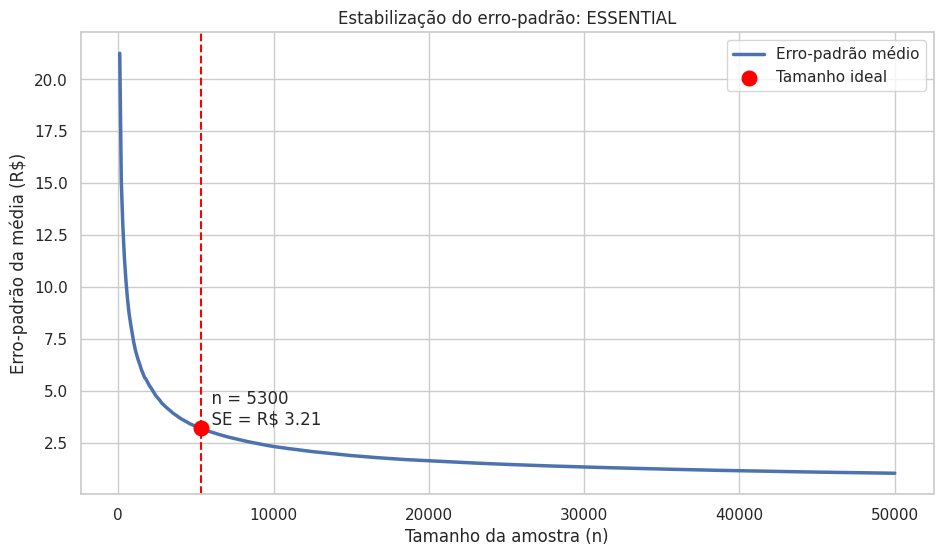

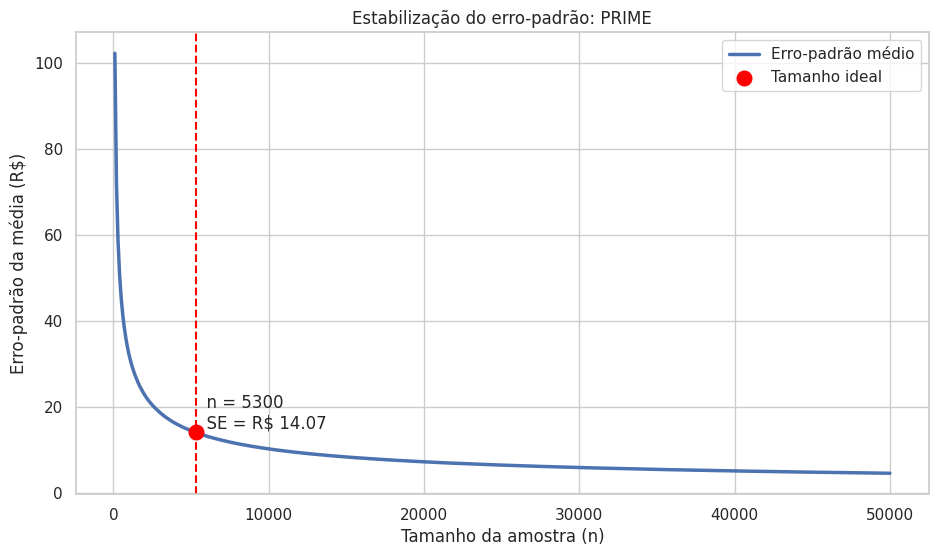

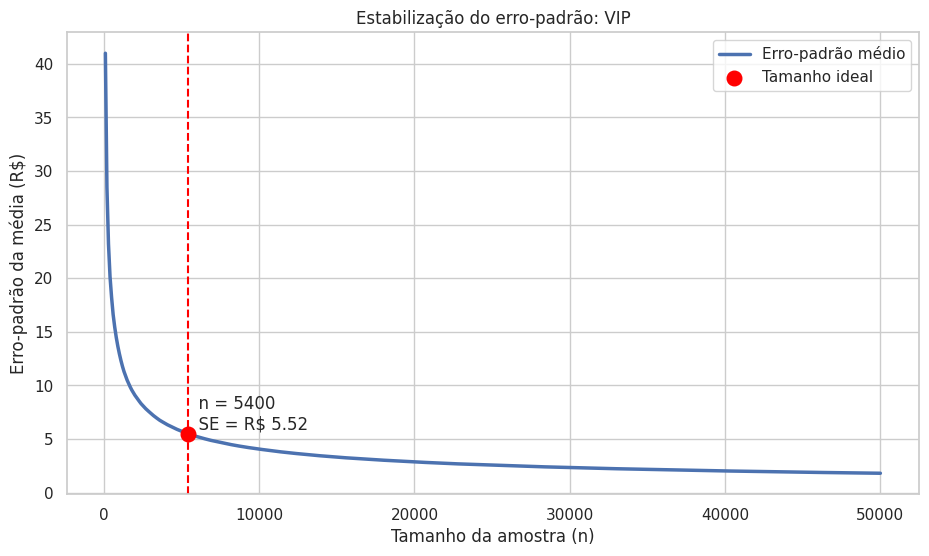

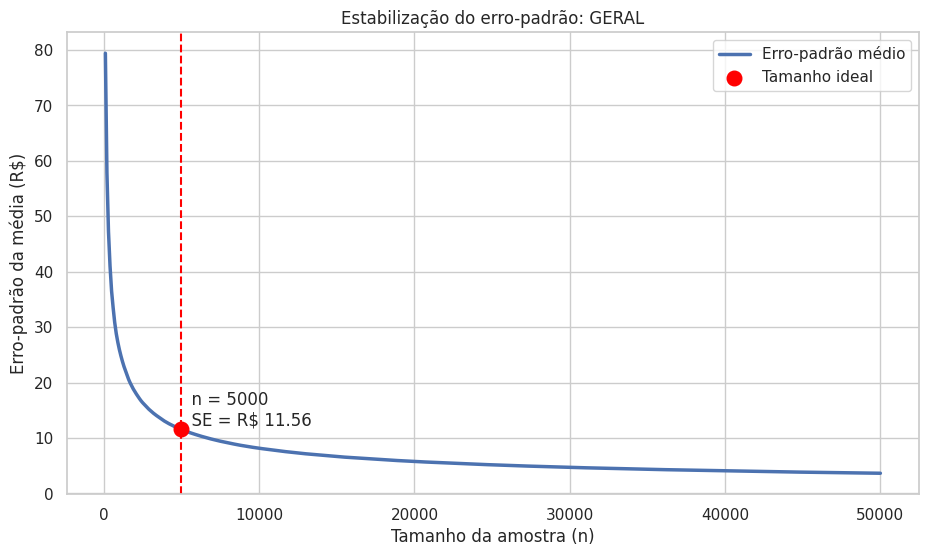

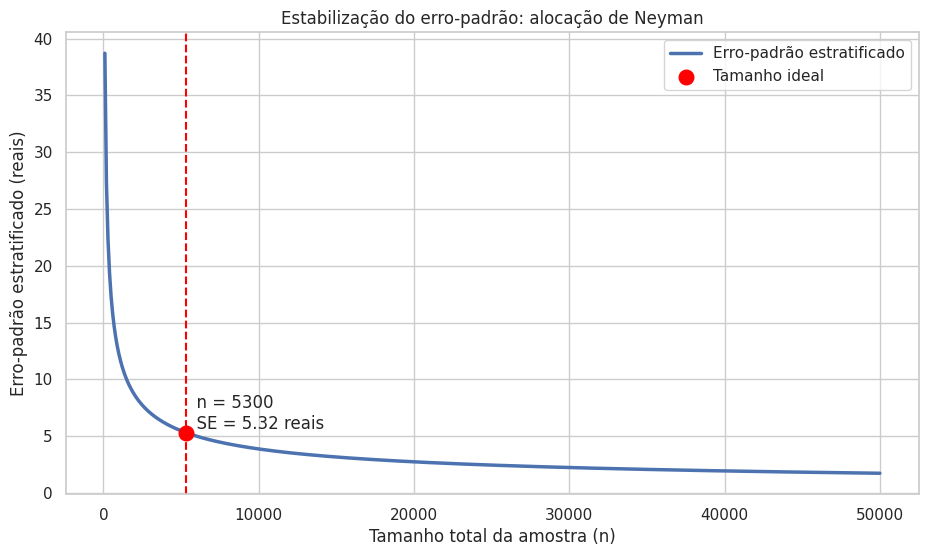

Tamanho ideal por procedimento:


,Grupo,Peso na população,n ideal (no grupo),SE no ponto (R$),n total equivalente
0,ESSENTIAL,0.6399,5300,3.2056,8283
1,PRIME,0.1489,5300,14.0710,35600
2,VIP,0.2113,5400,5.5187,25561
3,GERAL,1.0000,5000,11.5565,5000
4,NEYMAN (estratificado),1.0000,5300,5.3174,5300


Alocação de Neyman para 5300 notas fiscais:


,Stratum,Population Weight (Wh),Std. Deviation (Sh),Neyman Weight (Wh x Sh),Allocated Sample (nh),Allocated Sample (%)
0,ESSENTIAL,0.6399,232.2147,148.5859,2034,0.3838
1,PRIME,0.1489,1026.4408,152.8141,2092,0.3948
2,VIP,0.2113,405.7144,85.7104,1173,0.2214


Com 5300 notas, uma amostra aleatória simples teria erro-padrão de R$ 11.20; com a estratificação de Neyman ele cai para R$ 5.32 (52.5% menor).
Análise bootstrap no tamanho ideal:


,Grupo,n,Média (R$),IC inferior (R$),IC superior (R$),Erro-padrão bootstrap (R$),Erro-padrão teórico (R$)
0,ESSENTIAL,3455,379.49,372.29,386.89,3.86,3.85
1,PRIME,804,2286.08,2215.13,2358.58,36.81,37.02
2,VIP,1141,879.08,856.79,902.88,11.71,11.72
3,GERAL,5400,762.25,740.39,783.99,11.12,10.97


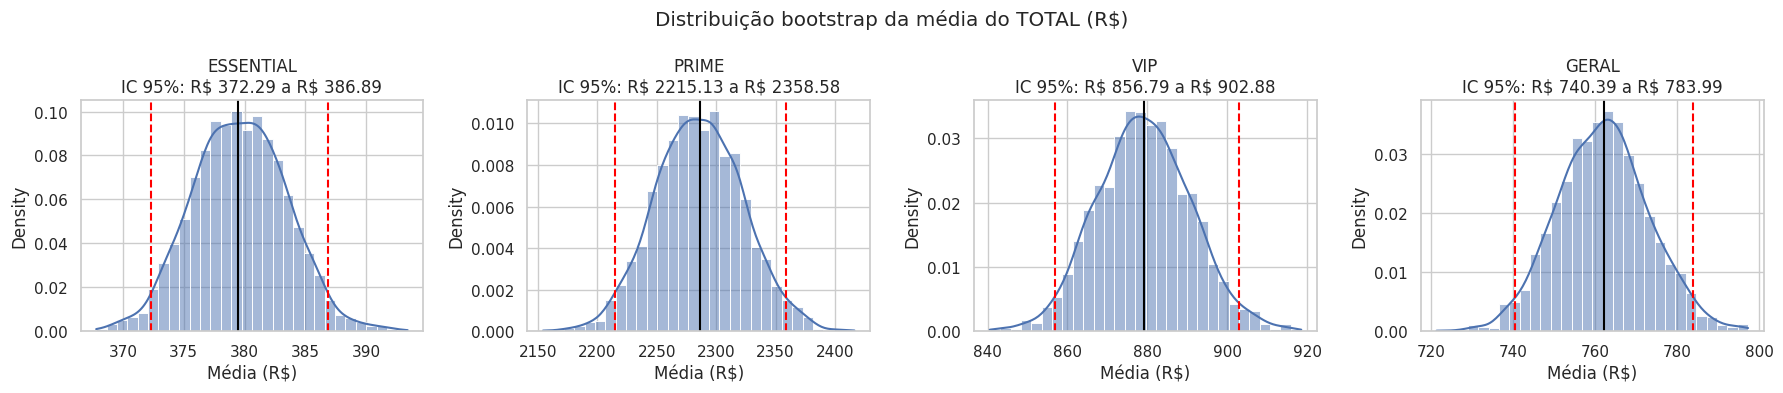

Sensibilidade do tamanho ideal (Neyman) ao limiar de estabilização:


,Limiar (%),n ideal,Erro-padrão estratificado (R$)
0,2.0,2800,7.32
1,1.0,5300,5.32
2,0.5,10300,3.81


Tamanho ideal da amostra: 5400 notas fiscais (definido por VIP, critério bruto).


In [49]:
resultado_a11 = AtividadeA1_1()

In [50]:
help(AtividadeA1_1)

Help on function AtividadeA1_1 in module __main__:

AtividadeA1_1(
    df=None,
    value_column='TOTAL (R$)',
    strata_column='TIPO DA CONTA',
    n_min=100,
    n_max=50000,
    step=100,
    limiar=0.01,
    pontos_consecutivos=3,
    repeticoes=30,
    semente=42,
    criterio='bruto',
    detalhado=True
)
    HELP:
    Atividade A1.1: determina o tamanho ideal da amostra.

    Gera os 4 gráficos do erro-padrão médio (ESSENTIAL, PRIME, VIP e GERAL)
    com o procedimento empírico prático (optimal_sample_size) e o gráfico da
    alocação de Neyman (optimal_stratified_sample_size), 5 gráficos no total.
    O tamanho ideal é o maior entre os tamanhos encontrados. Em seguida mostra
    a alocação de Neyman por estrato, o ganho da estratificação e a análise
    bootstrap (intervalo de confiança e erro-padrão) no tamanho ideal.

    Parâmetros
    ----------
    df : pandas.DataFrame, opcional
        Base completa. Se vazio usa a variável global table4.
    value_column, strata_column

**RESPONDER: Qual é o "Tamanho Ideal" da amostra?**

O erro-padrão médio do `TOTAL (R$)` estabilizou em **5.300** notas fiscais no ESSENTIAL, **5.300** no PRIME, **5.400** no VIP e **5.000** no conjunto GERAL (procedimento empírico prático, `optimal_sample_size`) e em **5.300** na alocação de Neyman (procedimento teórico, `optimal_stratified_sample_size`). Pela regra do projeto, o tamanho ideal é o maior deles: **5.400 notas fiscais**, definido pelo VIP.

Os cinco pontos ficaram na mesma faixa (5.000 a 5.400) porque o erro-padrão diminui na proporção de 1/√n: com o critério de três reduções seguidas menores que 1% a cada 100 notas, a estabilização acontece perto de 5.000 notas em qualquer grupo. O que muda de um grupo para outro é o nível do erro, que acompanha a variabilidade do gasto: 3,21 reais no ESSENTIAL, 5,52 reais no VIP e 14,07 reais no PRIME.

A estratificação reduz bastante o erro: com 5.300 notas, uma amostra aleatória simples teria erro-padrão de 11,20 reais, enquanto a alocação de Neyman chega a 5,32 reais (52,5% menor). A alocação de Neyman reparte as 5.300 notas em 2.034 no ESSENTIAL, 2.092 no PRIME e 1.173 no VIP: o PRIME, que tem só 14,9% das notas da base, recebe 39,5% da amostra por ser o estrato de maior variabilidade (desvio padrão de 1.026,44 reais, contra 405,71 reais no VIP e 232,21 reais no ESSENTIAL).

O limiar de 1% é o ponto de equilíbrio entre precisão e custo: com limiar de 2% o tamanho cairia para 2.800 notas, mas o erro-padrão estratificado subiria para 7,32 reais; com limiar de 0,5% o tamanho quase dobraria (10.300 notas) e o erro-padrão cairia apenas de 5,32 reais para 3,81 reais.

Na análise bootstrap com 5.400 notas (cada estrato com o seu peso na população), a média do gasto ficou em:

| Grupo | n | Média (reais) | IC 95% (reais) | Erro-padrão (reais) |
|---|---|---|---|---|
| ESSENTIAL | 3.455 | 379,49 | 372,29 a 386,89 | 3,86 |
| PRIME | 804 | 2.286,08 | 2.215,13 a 2.358,58 | 36,81 |
| VIP | 1.141 | 879,08 | 856,79 a 902,88 | 11,71 |
| GERAL | 5.400 | 762,25 | 740,39 a 783,99 | 11,12 |

O erro-padrão do bootstrap ficou praticamente igual ao teórico (desvio padrão dividido por √n) em todos os grupos, o que confirma as estimativas. Esses resultados são da base bruta; a Atividade A1.2 refaz o cálculo sem os outliers e confronta as duas rodadas.

###Atividade A1.2: Analisar os outliers

In [51]:
def remover_outliers_iqr(df, value_column=ALVO, strata_column=ESTRATO, k=1.5):
    """
    Remove outliers pelo critério do intervalo interquartil dentro de cada estrato.

    O corte é feito por estrato porque um gasto alto é normal numa conta PRIME
    e seria atípico numa ESSENTIAL. Valores fora de [Q1 - k*IQR, Q3 + k*IQR]
    são removidos.

    Parâmetros
    ----------
    df : pandas.DataFrame
        Base completa.
    value_column : str
        Variável alvo.
    strata_column : str
        Coluna dos estratos.
    k : float
        Multiplicador do IQR (1.5 padrão, 3.0 para outliers extremos).

    Retorna
    -------
    df_limpo : pandas.DataFrame
        Base sem os outliers.
    relatorio : pandas.DataFrame
        Por estrato e no total: observações, limites, quantidade e percentual
        de outliers e o maior valor removido.
    """
    manter = pd.Series(True, index=df.index)
    linhas = []

    for estrato, grupo in df.groupby(strata_column):
        q1, q3 = grupo[value_column].quantile([0.25, 0.75])
        iqr = q3 - q1
        inferior, superior = q1 - k * iqr, q3 + k * iqr
        fora = (grupo[value_column] < inferior) | (grupo[value_column] > superior)
        manter.loc[grupo.index[fora.to_numpy()]] = False
        linhas.append({
            "Estrato": estrato,
            "Observações": len(grupo),
            "Limite inferior": inferior,
            "Limite superior": superior,
            "Outliers": int(fora.sum()),
            "Outliers (%)": 100 * fora.mean(),
            "Maior outlier (R$)": grupo.loc[fora, value_column].max() if fora.any() else np.nan,
        })

    removidos = int((~manter).sum())
    linhas.append({
        "Estrato": "TOTAL",
        "Observações": len(df),
        "Limite inferior": np.nan,
        "Limite superior": np.nan,
        "Outliers": removidos,
        "Outliers (%)": 100 * removidos / len(df),
        "Maior outlier (R$)": df.loc[~manter, value_column].max() if removidos else np.nan,
    })

    return df[manter].copy(), pd.DataFrame(linhas)


def grafico_boxplot_estratos(df, value_column=ALVO, strata_column=ESTRATO, titulo=""):
    """
    Desenha um boxplot da variável alvo separado por estrato.

    Parâmetros
    ----------
    df : pandas.DataFrame
        Base a ser desenhada.
    value_column : str
        Variável alvo.
    strata_column : str
        Coluna dos estratos.
    titulo : str
        Texto complementar do título.
    """
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x=strata_column, y=value_column)
    plt.title(f"Distribuição do gasto por tipo de conta {titulo}".strip())
    plt.show()


def grafico_qq_estratos(df, value_column=ALVO, strata_column=ESTRATO, titulo="",
                        max_pontos=5000, semente=42):
    """
    Desenha um gráfico Q-Q normal para cada estrato e para o conjunto geral.

    Pontos sobre a reta indicam aderência à normal. Um salto vertical na ponta
    direita indica um grupo de valores separado do restante (valores atípicos),
    e não uma cauda natural. Em bases grandes cada painel usa uma amostra
    aleatória de até `max_pontos` valores para o gráfico não ficar pesado.

    Parâmetros
    ----------
    df : pandas.DataFrame
        Base ou amostra a ser avaliada.
    value_column : str
        Variável alvo.
    strata_column : str
        Coluna dos estratos.
    titulo : str
        Texto mostrado antes do nome de cada grupo.
    max_pontos : int
        Quantidade máxima de pontos por painel.
    semente : int
        Semente aleatória da amostra usada no gráfico.
    """
    grupos = [(g, d[value_column]) for g, d in df.groupby(strata_column)]
    grupos.append(("GERAL", df[value_column]))

    fig, eixos = plt.subplots(1, len(grupos), figsize=(4.5 * len(grupos), 4))
    for eixo, (grupo, valores) in zip(np.atleast_1d(eixos), grupos):
        if len(valores) > max_pontos:
            valores = valores.sample(max_pontos, random_state=semente)
        stats.probplot(valores, dist="norm", plot=eixo)
        eixo.set_title(f"{titulo}: {grupo}")
        eixo.set_xlabel("Quantis teóricos (normal)")
        eixo.set_ylabel("Valores observados (reais)")
    plt.tight_layout()
    plt.show()


def comparar_rodadas(bruta, limpa):
    """
    Coloca lado a lado o resultado da Atividade A1.1 com e sem outliers.

    Parâmetros
    ----------
    bruta, limpa : dict
        Retornos da AtividadeA1_1 na base bruta e na base sem outliers.

    Retorna
    -------
    pandas.DataFrame
        n ideal, erro-padrão no ponto e média bootstrap de cada grupo nas duas rodadas.
    """
    colunas = ["n ideal (no grupo)", "SE no ponto (R$)"]
    a = bruta["tabela"].set_index("Grupo")[colunas]
    b = limpa["tabela"].set_index("Grupo")[colunas]
    comparacao = a.join(b, lsuffix=" - bruta", rsuffix=" - sem outliers")

    media_a = bruta["bootstrap"].set_index("Grupo")["Média (R$)"].rename("Média (R$) - bruta")
    media_b = limpa["bootstrap"].set_index("Grupo")["Média (R$)"].rename("Média (R$) - sem outliers")
    return comparacao.join(media_a).join(media_b).round(2)


def AtividadeA1_2(df=None, resultado_anterior=None, k=1.5):
    """
    HELP:
    Atividade A1.2: analisa os outliers, remove-os, recalcula o tamanho ideal
    e confronta as duas rodadas.

    Etapas:
    1. Boxplot e gráfico Q-Q de cada estrato na base bruta, para ver se os
       valores atípicos formam uma cauda contínua ou um grupo separado.
    2. Identificação e remoção dos outliers pelo IQR dentro de cada estrato.
    3. Nova execução da Atividade A1.1 na base sem outliers (5 gráficos).
    4. Tabela de confronto entre as duas rodadas.

    Pela regra do projeto, o tamanho ideal final é o maior n encontrado nas
    duas rodadas.

    Parâmetros
    ----------
    df : pandas.DataFrame, opcional
        Base completa. Se vazio usa a variável global table4.
    resultado_anterior : dict, opcional
        Retorno da AtividadeA1_1 com a base bruta. Se vazio ela é executada aqui.
    k : float
        Multiplicador do IQR (1.5 padrão).

    Retorna
    -------
    dict
        base (sem outliers), n_ideal (final), n_bruta, n_limpa, relatorio,
        comparacao e resultado (rodada sem outliers).
    """
    if df is None:
        df = table4
    if resultado_anterior is None:
        resultado_anterior = AtividadeA1_1(df)

    grafico_boxplot_estratos(df, titulo="(base bruta)")
    grafico_qq_estratos(df, titulo="Base bruta")

    base_limpa, relatorio = remover_outliers_iqr(df, k=k)
    display(relatorio.round(2))
    grafico_boxplot_estratos(base_limpa, titulo="(sem outliers)")

    print(f"Recalculando o tamanho ideal sem os outliers ({len(base_limpa)} notas fiscais):")
    novo = AtividadeA1_1(base_limpa, detalhado=False)

    comparacao = comparar_rodadas(resultado_anterior, novo)
    print("Confronto entre as duas rodadas:")
    display(comparacao)

    n_bruta, n_limpa = resultado_anterior["n_ideal"], novo["n_ideal"]
    n_final = max(n_bruta, n_limpa)
    print(f"Tamanho ideal: {n_bruta} na base bruta e {n_limpa} sem outliers. "
          f"Tamanho ideal final: {n_final} notas fiscais (o maior entre as duas rodadas).")

    return {
        "base": base_limpa,
        "n_ideal": n_final,
        "n_bruta": n_bruta,
        "n_limpa": n_limpa,
        "relatorio": relatorio,
        "comparacao": comparacao,
        "resultado": novo,
    }

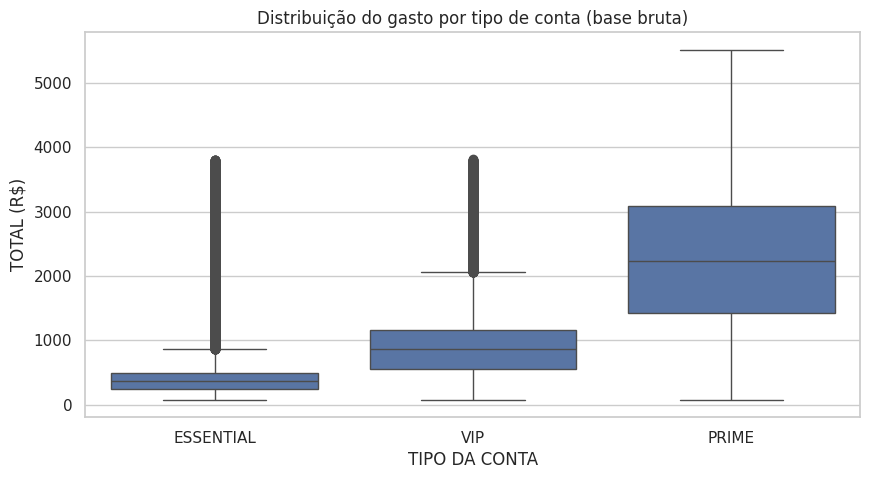

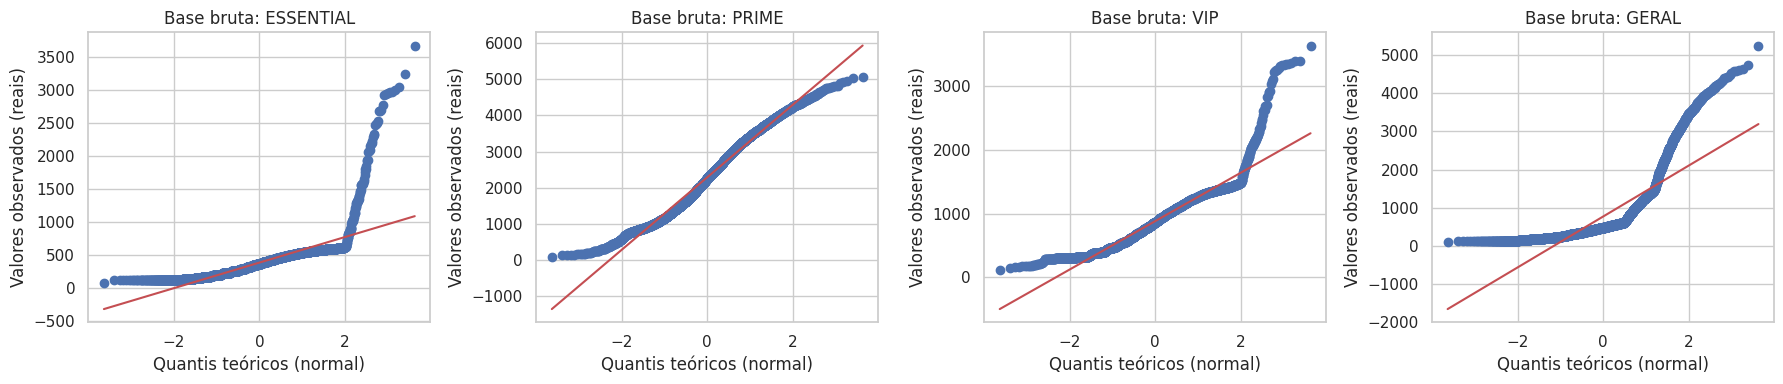

,Estrato,Observações,Limite inferior,Limite superior,Outliers,Outliers (%),Maior outlier (R$)
0,ESSENTIAL,716648,-144.98,867.74,9889,1.38,3805.87
1,PRIME,166743,-1097.59,5608.27,0,0.00,NaN
2,VIP,236609,-343.77,2063.32,3104,1.31,3813.05
3,TOTAL,1120000,NaN,NaN,12993,1.16,3813.05


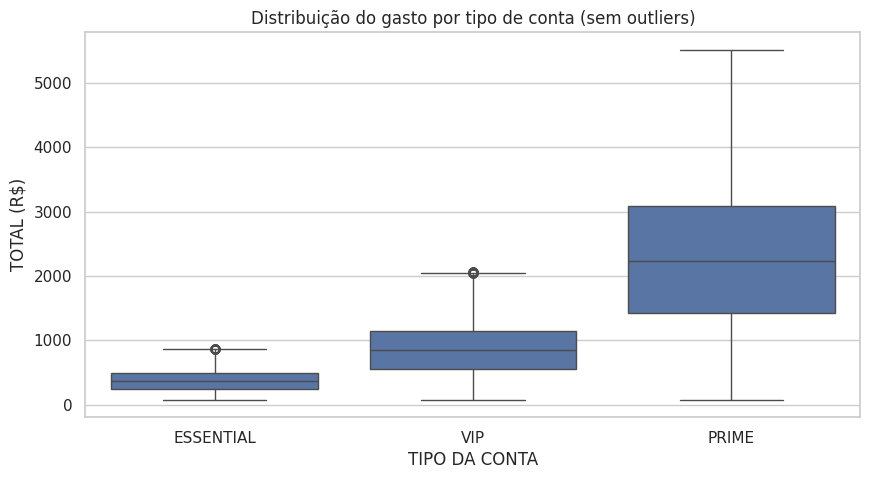

Recalculando o tamanho ideal sem os outliers (1107007 notas fiscais):


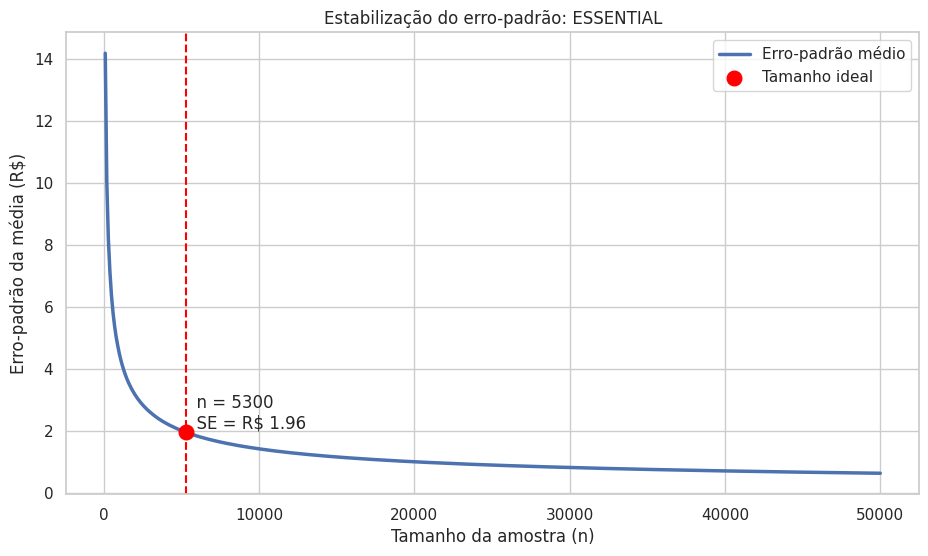

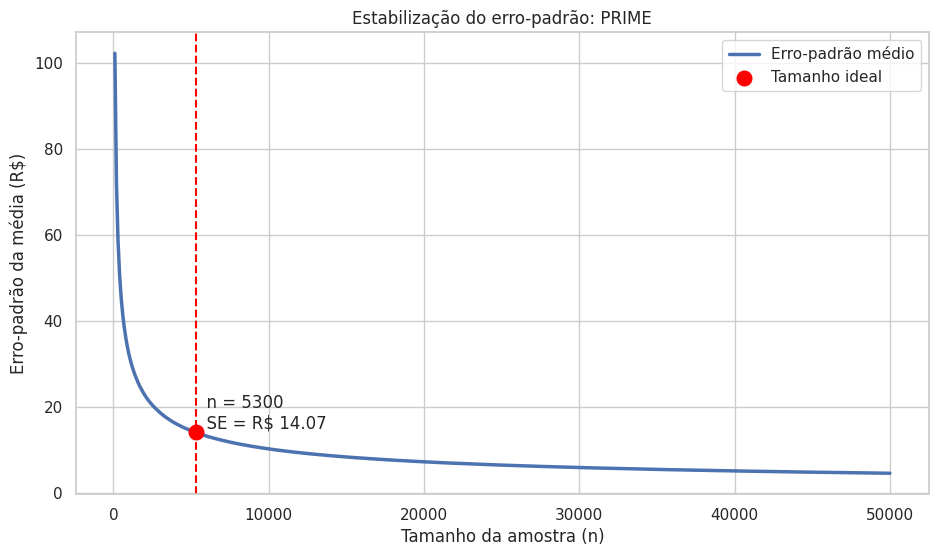

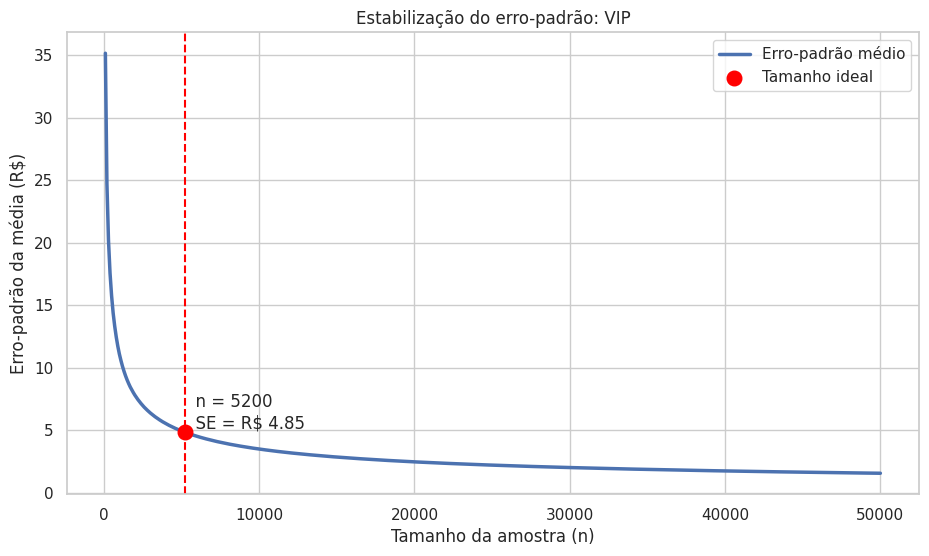

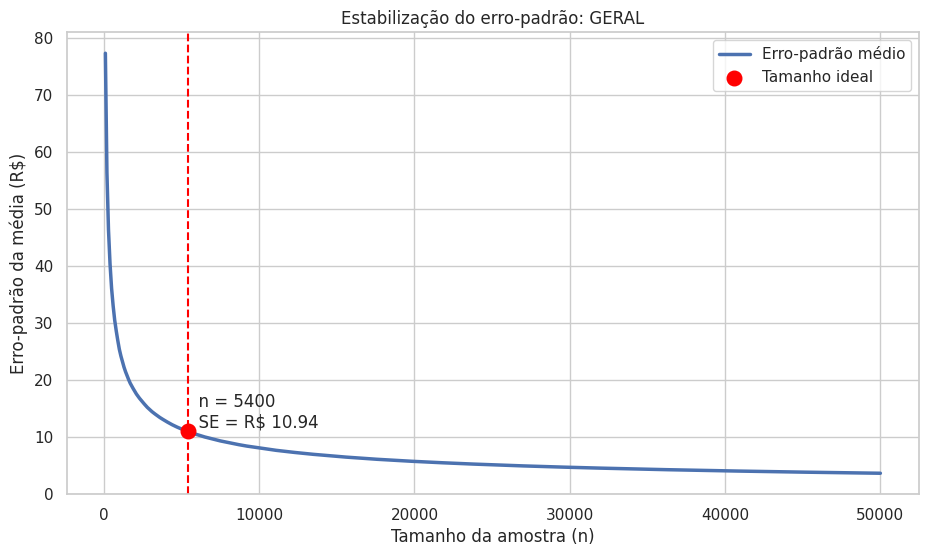

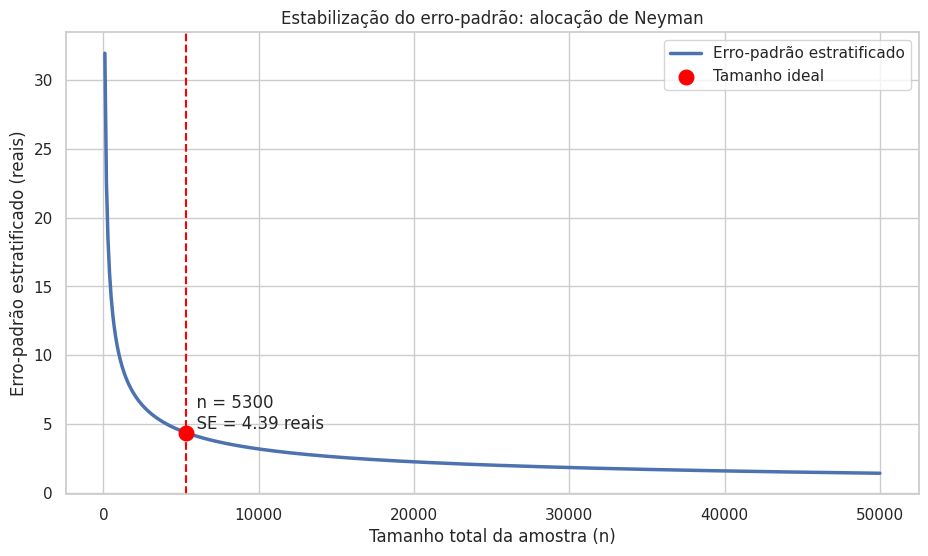

Tamanho ideal por procedimento:


,Grupo,Peso na população,n ideal (no grupo),SE no ponto (R$),n total equivalente
0,ESSENTIAL,0.6384,5300,1.9578,8301
1,PRIME,0.1506,5300,14.0710,35187
2,VIP,0.2109,5200,4.8520,24652
3,GERAL,1.0000,5400,10.9430,5400
4,NEYMAN (estratificado),1.0000,5300,4.3874,5300


Alocação de Neyman para 5300 notas fiscais:


,Stratum,Population Weight (Wh),Std. Deviation (Sh),Neyman Weight (Wh x Sh),Allocated Sample (nh),Allocated Sample (%)
0,ESSENTIAL,0.6384,142.3891,90.9071,1508,0.2846
1,PRIME,0.1506,1026.4408,154.6077,2565,0.4841
2,VIP,0.2109,350.3099,73.8921,1226,0.2314


Com 5300 notas, uma amostra aleatória simples teria erro-padrão de R$ 11.07; com a estratificação de Neyman ele cai para R$ 4.39 (60.4% menor).
Análise bootstrap no tamanho ideal:


,Grupo,n,Média (R$),IC inferior (R$),IC superior (R$),Erro-padrão bootstrap (R$),Erro-padrão teórico (R$)
0,ESSENTIAL,3448,362.97,358.34,367.29,2.34,2.41
1,PRIME,813,2297.35,2226.93,2365.82,36.22,35.48
2,VIP,1139,865.22,844.72,886.51,10.67,10.56
3,GERAL,5400,760.31,739.26,781.63,10.90,11.05


Tamanho ideal da amostra: 5400 notas fiscais (definido por GERAL, critério bruto).
Confronto entre as duas rodadas:


,n ideal (no grupo) - bruta,SE no ponto (R$) - bruta,n ideal (no grupo) - sem outliers,SE no ponto (R$) - sem outliers,Média (R$) - bruta,Média (R$) - sem outliers
Grupo,,,,,,
ESSENTIAL,5300,3.21,5300,1.96,379.49,362.97
PRIME,5300,14.07,5300,14.07,2286.08,2297.35
VIP,5400,5.52,5200,4.85,879.08,865.22
GERAL,5000,11.56,5400,10.94,762.25,760.31
NEYMAN (estratificado),5300,5.32,5300,4.39,NaN,NaN


Tamanho ideal: 5400 na base bruta e 5400 sem outliers. Tamanho ideal final: 5400 notas fiscais (o maior entre as duas rodadas).
Base usada nos testes: 1107007 notas fiscais, n ideal = 5400


In [52]:
resultado_a12 = AtividadeA1_2(resultado_anterior=resultado_a11)

base_final = resultado_a12["base"]
n_ideal = resultado_a12["n_ideal"]
print(f"Base usada nos testes: {len(base_final)} notas fiscais, n ideal = {n_ideal}")

**Conclusão dos outliers**

Pelo critério do intervalo interquartil (IQR), aplicado dentro de cada estrato, foram identificados **12.993 outliers (1,16% das notas fiscais)**: 9.889 no ESSENTIAL (1,38%, acima de 867,74 reais), 3.104 no VIP (1,31%, acima de 2.063,32 reais) e nenhum no PRIME (limites de -1.097,59 reais a 5.608,27 reais).

Esses valores não são uma cauda natural do gasto. No gráfico Q-Q os pontos do ESSENTIAL e do VIP seguem a reta até cerca de 2 desvios e depois dão um salto vertical, e no boxplot os outliers dos dois estratos formam uma faixa contínua que termina praticamente no mesmo teto (3.805,87 reais no ESSENTIAL e 3.813,05 reais no VIP), embora os estratos tenham níveis de gasto muito diferentes. É o comportamento do "erro aleatório" dos exemplos dos Tópicos I e II, por isso os outliers foram removidos e a análise segue com 1.107.007 notas fiscais.

Com a base sem outliers o tamanho ideal foi recalculado: 5.300 no ESSENTIAL, 5.300 no PRIME, 5.200 no VIP, 5.400 no GERAL e 5.300 na alocação de Neyman. O ponto de estabilização continuou na mesma faixa (5.200 a 5.400), mas o erro-padrão caiu (ESSENTIAL de 3,21 reais para 1,96 reais e VIP de 5,52 reais para 4,85 reais) e as médias deixaram de ser puxadas para cima (ESSENTIAL de 379,49 reais para 362,97 reais e VIP de 879,08 reais para 865,22 reais). O PRIME não muda, porque não tinha outliers. Na alocação de Neyman, o erro-padrão caiu de 5,32 reais para 4,39 reais, 60,4% menor que o de uma amostra aleatória simples do mesmo tamanho (11,07 reais).

Confrontando as duas rodadas, as duas chegam ao mesmo valor máximo (5.400 na base bruta, pelo VIP, e 5.400 sem outliers, pelo GERAL). O **tamanho ideal final é de 5.400 notas fiscais**, e é ele que segue para os testes de hipóteses e para as atividades A2 e A3.

In [53]:
def impacto_entrada_diaria(n, N_atual, entrada_diaria=ENTRADA_DIARIA, dias=(0, 30, 180, 365)):
    """
    Mostra o efeito da entrada diária de notas fiscais sobre o tamanho ideal.

    Calcula a fração amostral (n/N) e o fator de correção para população
    finita, raiz((N - n) / (N - 1)), para a base atual e para a base depois
    de alguns dias de entrada de notas. Um fator praticamente igual a 1
    justifica tratar a população como infinita.

    Parâmetros
    ----------
    n : int
        Tamanho ideal da amostra.
    N_atual : int
        Quantidade de notas fiscais na base hoje.
    entrada_diaria : int
        Notas fiscais novas por dia.
    dias : tuple of int
        Horizontes avaliados, em dias.

    Retorna
    -------
    pandas.DataFrame
        Tamanho da base, fração amostral, fator de correção e redução do
        erro-padrão em cada horizonte.
    """
    linhas = []
    for d in dias:
        N = N_atual + d * entrada_diaria
        fator = np.sqrt((N - n) / (N - 1))
        linhas.append({
            "Dias": d,
            "Notas na base": N,
            "Fração amostral (%)": 100 * n / N,
            "Fator de correção": fator,
            "Redução do erro-padrão (%)": 100 * (1 - fator),
        })
    print(f"A amostra ideal equivale a {n / entrada_diaria:.2f} dia(s) de entrada de notas fiscais.")
    return pd.DataFrame(linhas).round(4)


impacto_entrada_diaria(n_ideal, len(table4))

A amostra ideal equivale a 1.08 dia(s) de entrada de notas fiscais.


,Dias,Notas na base,Fração amostral (%),Fator de correção,Redução do erro-padrão (%)
0,0,1120000,0.4821,0.9976,0.2413
1,30,1270000,0.4252,0.9979,0.2128
2,180,2020000,0.2673,0.9987,0.1337
3,365,2945000,0.1834,0.9991,0.0917


**Efeito da entrada diária de 5.000 notas fiscais**

A base recebe cerca de 5.000 notas fiscais novas por dia, por isso foi tratada como uma população infinita. A tabela confirma essa premissa: a amostra de 5.400 notas representa só 0,48% da base atual, e a correção para população finita reduziria o erro-padrão em apenas 0,24%. Com a entrada diária essa fração cai ainda mais, para 0,18% depois de um ano. Ou seja, o crescimento da base não altera o tamanho ideal, que depende só da variabilidade do gasto.

Na prática, a amostra ideal equivale a cerca de 1,1 dia de entrada de notas. Isso permite renovar a amostra diariamente e repetir o procedimento periodicamente, para acompanhar mudanças no perfil de gasto. Como a base não tem a data de emissão das notas, não foi possível verificar se as notas novas têm o mesmo perfil das antigas; essa é uma limitação desta análise.

###Atividade A1.3: Testes de Hipóteses ([Link](https://colab.research.google.com/drive/1_YGamH-qOWSNaCKG5kVlLiZPuXv5lT34?usp=sharing))

In [54]:
def sortear_duas_amostras(df, n, semente=42):
    """
    Sorteia duas amostras aleatórias sem reposição e sem linhas em comum.

    Parâmetros
    ----------
    df : pandas.DataFrame
        Base de onde as amostras saem.
    n : int
        Tamanho de cada amostra.
    semente : int
        Semente aleatória.

    Retorna
    -------
    sample1, sample2 : pandas.DataFrame
        Duas amostras disjuntas com n linhas cada.
    """
    if 2 * n > len(df):
        raise ValueError("A base não tem linhas suficientes para duas amostras disjuntas.")

    rng = np.random.default_rng(semente)
    ordem = rng.permutation(len(df))
    return df.iloc[ordem[:n]].copy(), df.iloc[ordem[n:2 * n]].copy()


sample1, sample2 = sortear_duas_amostras(base_final, n_ideal)
print(sample1.shape, sample2.shape)

(5400, 23) (5400, 23)


In [55]:
def p_pearson(x, y):
    """Retorna o p-valor da correlação de Pearson entre x e y."""
    return stats.pearsonr(x, y)[1]


def p_spearman(x, y):
    """Retorna o p-valor da correlação de postos de Spearman entre x e y."""
    return stats.spearmanr(x, y)[1]


def p_kendall(x, y):
    """Retorna o p-valor do tau de Kendall entre x e y."""
    return stats.kendalltau(x, y)[1]


def p_qui_quadrado(x, y, faixas=10):
    """
    Retorna o p-valor do qui-quadrado de independência.

    Os valores são discretizados em `faixas` quantis para formar a tabela de
    contingência entre x e y.
    """
    fx = pd.qcut(x, faixas, labels=False, duplicates="drop")
    fy = pd.qcut(y, faixas, labels=False, duplicates="drop")
    return stats.chi2_contingency(pd.crosstab(fx, fy))[1]


def p_ks(x, y):
    """Retorna o p-valor do teste de Kolmogorov-Smirnov de duas amostras."""
    return stats.ks_2samp(x, y)[1]


def p_mann_whitney(x, y):
    """Retorna o p-valor do teste U de Mann-Whitney."""
    return stats.mannwhitneyu(x, y)[1]


def p_kruskal(x, y):
    """Retorna o p-valor do teste de Kruskal-Wallis."""
    return stats.kruskal(x, y)[1]


def p_anova(x, y):
    """Retorna o p-valor da ANOVA de um fator (f_oneway) entre x e y."""
    return stats.f_oneway(x, y)[1]


def p_t_student(x, y):
    """Retorna o p-valor do teste t de Student (variâncias iguais)."""
    return stats.ttest_ind(x, y)[1]


def p_t_welch(x, y):
    """Retorna o p-valor do teste t de Welch (variâncias diferentes)."""
    return stats.ttest_ind(x, y, equal_var=False)[1]

In [56]:
def testes_independencia():
    """Testes de independência entre SAMPLE 1 e SAMPLE 2: nome -> (função, paramétrico)."""
    return {
        "Pearson": (p_pearson, True),
        "Spearman": (p_spearman, False),
        "Kendall": (p_kendall, False),
        "Qui-quadrado": (p_qui_quadrado, False),
    }


def testes_distribuicao():
    """Testes de mesma distribuição entre SAMPLE 1 e SAMPLE 2: nome -> (função, paramétrico)."""
    return {
        "Kolmogorov-Smirnov": (p_ks, False),
        "Mann-Whitney": (p_mann_whitney, False),
        "Kruskal-Wallis": (p_kruskal, False),
        "ANOVA": (p_anova, True),
    }



def testes_medias():
    """
    Testes de igualdade de médias entre SAMPLE 1 e SAMPLE 2: nome -> (função, paramétrico).

    O t de Welch vem primeiro porque não exige variâncias iguais; em caso de
    empate na precisão ele é o escolhido.
    """
    return {
        "t de Welch": (p_t_welch, True),
        "t de Student": (p_t_student, True),
        "ANOVA": (p_anova, True),
    }

In [57]:
def bootstrap_pvalores(df, n, testes, value_column=ALVO, repeticoes=1000, semente=42):
    """
    Repete o sorteio de duas amostras disjuntas e guarda o p-valor de cada teste.

    Em cada repetição sorteia SAMPLE 1 e SAMPLE 2 de tamanho n a partir da base
    e aplica todos os testes do dicionário nos mesmos pares de amostras. A
    distribuição dos p-valores mostra o quanto a conclusão é estável.

    Parâmetros
    ----------
    df : pandas.DataFrame
        Base de onde as amostras saem.
    n : int
        Tamanho de cada amostra (o tamanho ideal).
    testes : dict
        Nome -> (função, paramétrico), como em `testes_independencia()`.
    value_column : str
        Variável alvo.
    repeticoes : int
        Número de pares de amostras sorteados.
    semente : int
        Semente aleatória.

    Retorna
    -------
    pandas.DataFrame
        Uma coluna por teste e uma linha por repetição com o p-valor.
    """
    valores = pd.to_numeric(df[value_column], errors="coerce").dropna().to_numpy(dtype=float)
    if 2 * n > len(valores):
        raise ValueError("A base não tem linhas suficientes para duas amostras disjuntas.")

    rng = np.random.default_rng(semente)
    pvalores = {nome: np.empty(repeticoes) for nome in testes}

    for b in range(repeticoes):
        indices = rng.choice(len(valores), size=2 * n, replace=False)
        x = valores[indices[:n]]
        y = valores[indices[n:]]
        for nome, (funcao, _) in testes.items():
            pvalores[nome][b] = funcao(x, y)

    return pd.DataFrame(pvalores)


def resumir_pvalores(pvalores, testes, alpha=0.05, observados=None):
    """
    Resume a distribuição bootstrap dos p-valores de cada teste.

    A coluna "Precisão (%)" é a porcentagem de repetições em que H0 não foi
    rejeitada. Se H0 é verdadeira o valor esperado fica perto de 100*(1-alpha).
    Quando `observados` é informado, a tabela traz também o p-valor do teste
    aplicado nas duas amostras sorteadas (SAMPLE 1 e SAMPLE 2).

    Parâmetros
    ----------
    pvalores : pandas.DataFrame
        Saída de `bootstrap_pvalores`.
    testes : dict
        Dicionário de testes usado no bootstrap.
    alpha : float
        Nível de significância.
    observados : dict, opcional
        Nome do teste -> p-valor em SAMPLE 1 x SAMPLE 2.

    Retorna
    -------
    pandas.DataFrame
        p-valor observado (%), p-valor mediano, médio, percentis 2,5% e 97,5%
        e precisão em %.
    """
    linhas = []
    for nome in pvalores.columns:
        p = pvalores[nome]
        linha = {"Teste": nome, "Paramétrico": testes[nome][1]}
        if observados is not None:
            linha["p-valor SAMPLE 1 x 2 (%)"] = 100 * observados[nome]
        linha.update({
            "p mediano": p.median(),
            "p médio": p.mean(),
            "p 2,5%": p.quantile(0.025),
            "p 97,5%": p.quantile(0.975),
            "Precisão (%)": 100 * (p > alpha).mean(),
        })
        linhas.append(linha)
    return pd.DataFrame(linhas)


def grafico_bootstrap_pvalores(pvalores, alpha=0.05, titulo=""):
    """
    Desenha o histograma bootstrap dos p-valores de cada teste.

    A linha vermelha marca o nível de significância. Barras à direita dela
    são repetições em que H0 não foi rejeitada.

    Parâmetros
    ----------
    pvalores : pandas.DataFrame
        Saída de `bootstrap_pvalores`.
    alpha : float
        Nível de significância.
    titulo : str
        Título geral da figura.
    """
    colunas = list(pvalores.columns)
    fig, eixos = plt.subplots(1, len(colunas), figsize=(4.5 * len(colunas), 4), sharey=True)

    for eixo, nome in zip(np.atleast_1d(eixos), colunas):
        precisao = 100 * (pvalores[nome] > alpha).mean()
        sns.histplot(pvalores[nome], bins=20, binrange=(0, 1), ax=eixo)
        eixo.axvline(alpha, color="red", linestyle="--")
        eixo.set_title(f"{nome}\nprecisão {precisao:.1f}%")
        eixo.set_xlabel("p-valor")

    fig.suptitle(titulo)
    plt.tight_layout()
    plt.show()


def escolher_melhor_ajuste(resumo, permitir_parametricos):
    """
    Escolhe o teste de melhor ajuste entre os candidatos.

    Se os paramétricos não são permitidos (normalidade rejeitada) só os testes
    não paramétricos entram. Entre os candidatos vence o de maior precisão; o
    p-valor mediano desempata e, persistindo o empate, vale a ordem do
    dicionário de testes.

    Parâmetros
    ----------
    resumo : pandas.DataFrame
        Saída de `resumir_pvalores`.
    permitir_parametricos : bool
        Se False descarta os testes paramétricos.

    Retorna
    -------
    pandas.Series
        Linha do teste escolhido.
    """
    candidatos = resumo if permitir_parametricos else resumo[~resumo["Paramétrico"]]
    candidatos = candidatos.sort_values(["Precisão (%)", "p mediano"], ascending=False,
                                        kind="mergesort")
    return candidatos.iloc[0]


def executar_familia_testes(df, n, testes, permitir_parametricos, titulo,
                            alpha=0.05, repeticoes=1000, semente=42,
                            x_obs=None, y_obs=None):
    """
    Executa uma família de testes em SAMPLE 1 x SAMPLE 2 e no bootstrap.

    Calcula o p-valor de cada teste nas duas amostras sorteadas, repete o
    sorteio de pares de amostras para medir a precisão, desenha os
    histogramas dos p-valores e escolhe o teste de melhor ajuste.

    Parâmetros
    ----------
    df : pandas.DataFrame
        Base de onde as amostras saem.
    n : int
        Tamanho ideal da amostra.
    testes : dict
        Dicionário de testes (independência, distribuição ou médias).
    permitir_parametricos : bool
        Se os testes paramétricos podem concorrer ao melhor ajuste.
    titulo : str
        Título do gráfico.
    alpha : float
        Nível de significância.
    repeticoes : int
        Repetições do bootstrap.
    semente : int
        Semente aleatória.
    x_obs, y_obs : array-like, opcional
        Valores da SAMPLE 1 e da SAMPLE 2.

    Retorna
    -------
    resumo : pandas.DataFrame
        Tabela resumo dos testes.
    melhor : pandas.Series
        Teste de melhor ajuste.
    pvalores : pandas.DataFrame
        p-valores de todas as repetições.
    """
    observados = None
    if x_obs is not None and y_obs is not None:
        x = np.asarray(x_obs, dtype=float)
        y = np.asarray(y_obs, dtype=float)
        observados = {nome: funcao(x, y) for nome, (funcao, _) in testes.items()}

    pvalores = bootstrap_pvalores(df, n, testes, repeticoes=repeticoes, semente=semente)
    resumo = resumir_pvalores(pvalores, testes, alpha, observados)
    grafico_bootstrap_pvalores(pvalores, alpha, titulo)
    melhor = escolher_melhor_ajuste(resumo, permitir_parametricos)
    print(f"Melhor ajuste: {melhor['Teste']} com precisão de {melhor['Precisão (%)']:.1f}%")
    return resumo, melhor, pvalores


def concluir_familia(melhor, repeticoes, alpha, afirmacao, negacao):
    """
    Escreve a conclusão de uma família de testes a partir do bootstrap.

    Quando H0 é verdadeira, a porcentagem de pares de amostras em que H0 não
    é rejeitada segue uma binomial em torno de 100*(1-alpha). Se a precisão
    do melhor ajuste não fica abaixo dessa faixa, H0 é mantida. O p-valor do
    par sorteado (SAMPLE 1 x SAMPLE 2) é informado à parte: uma rejeição
    isolada nesse par acontece por acaso em cerca de alpha dos sorteios.

    Parâmetros
    ----------
    melhor : pandas.Series
        Linha do teste de melhor ajuste.
    repeticoes : int
        Repetições do bootstrap.
    alpha : float
        Nível de significância.
    afirmacao, negacao : str
        Textos usados quando H0 é mantida ou rejeitada.

    Retorna
    -------
    bool
        True se H0 foi mantida.
    """
    baixo, alto = stats.binom.interval(0.95, repeticoes, 1 - alpha)
    baixo, alto = 100 * baixo / repeticoes, 100 * alto / repeticoes
    precisao = melhor["Precisão (%)"]
    p_obs = melhor["p-valor SAMPLE 1 x 2 (%)"]
    mantida = precisao >= baixo

    print(f"Conclusão: SAMPLE 1 e SAMPLE 2 {afirmacao if mantida else negacao}. "
          f"Melhor ajuste: {melhor['Teste']}, precisão de {precisao:.1f}% em {repeticoes} "
          f"pares de amostras (faixa esperada se H0 for verdadeira: {baixo:.1f}% a {alto:.1f}%).")
    if p_obs > 100 * alpha:
        print(f"No par sorteado, o p-valor foi de {p_obs:.2f}%, acima de {100 * alpha:.0f}%.")
    elif mantida:
        print(f"No par sorteado, o p-valor foi de {p_obs:.2f}%: uma rejeição isolada, dentro dos "
              f"{100 * alpha:.0f}% de falso positivo esperados, como mostra o bootstrap.")
    else:
        print(f"No par sorteado, o p-valor foi de {p_obs:.2f}%.")
    return mantida

#### A1.3.1: Teste de Normalidade

Nesta ETAPA, você deve fazer o **TESTE DE HIPÓTESE DE NORMALIDADE: Anderson-Darling' Test (AD test)** sobre:

*   SAMPLE 1:
*   SAMPLE 2:

,Amostra,Grupo,n,AD estatística,Valor crítico (5%),Normal (5%),Assimetria,Curtose (excesso)
0,SAMPLE 1,ESSENTIAL,3459,40.0088,0.786,False,0.0103,-1.0955
1,SAMPLE 1,PRIME,804,5.7820,0.783,False,0.1900,-0.8972
2,SAMPLE 1,VIP,1137,10.3101,0.784,False,0.0744,-0.9317
3,SAMPLE 1,GERAL,5400,589.4057,0.786,False,2.3998,5.6923


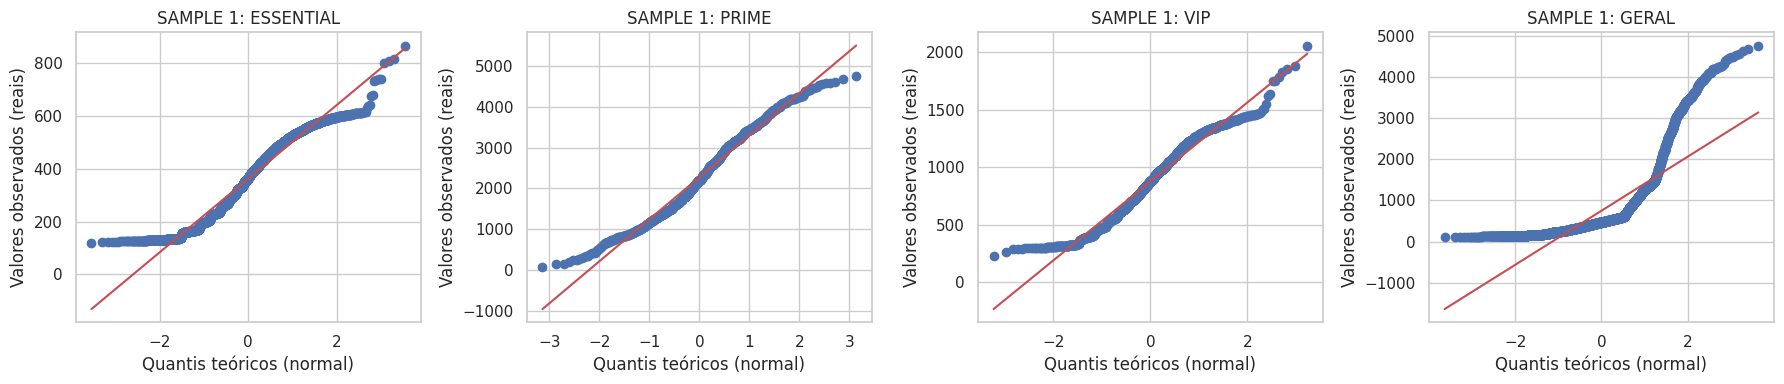

In [58]:
def teste_normalidade_ad(valores, nivel=5.0):
    """
    Aplica o teste de normalidade de Anderson-Darling.

    A decisão compara a estatística AD com o valor crítico do nível escolhido:
    se a estatística for menor, não se rejeita a normalidade. Nas versões do
    SciPy que já não trazem a tabela de valores críticos, a decisão usa o
    p-valor.

    Parâmetros
    ----------
    valores : array-like
        Amostra numérica.
    nivel : float
        Nível de significância em % (5.0 = 5%).

    Retorna
    -------
    dict
        Estatística AD, valor crítico, decisão de normalidade, assimetria e
        curtose em excesso.
    """
    valores = np.asarray(valores, dtype=float)

    try:
        res = stats.anderson(valores, dist="norm")
        niveis = [float(s) for s in res.significance_level]
        critico = float(res.critical_values[niveis.index(nivel)])
        estatistica = float(res.statistic)
        normal = estatistica < critico
    except (AttributeError, TypeError):
        res = stats.anderson(valores, dist="norm", method="interpolate")
        estatistica, critico = float(res.statistic), np.nan
        normal = float(res.pvalue) > nivel / 100

    return {
        "AD estatística": estatistica,
        "Valor crítico (5%)": critico,
        "Normal (5%)": bool(normal),
        "Assimetria": float(stats.skew(valores)),
        "Curtose (excesso)": float(stats.kurtosis(valores)),
    }


def normalidade_estratificada(amostra, nome, value_column=ALVO, strata_column=ESTRATO):
    """
    Roda o teste de Anderson-Darling por estrato e no conjunto geral de uma amostra.

    Parâmetros
    ----------
    amostra : pandas.DataFrame
        SAMPLE 1 ou SAMPLE 2.
    nome : str
        Nome da amostra na tabela.
    value_column : str
        Variável alvo.
    strata_column : str
        Coluna dos estratos.

    Retorna
    -------
    pandas.DataFrame
        Uma linha por grupo (estratos e GERAL).
    """
    grupos = [(g, d) for g, d in amostra.groupby(strata_column)]
    grupos.append(("GERAL", amostra))

    linhas = []
    for grupo, dados in grupos:
        resultado = teste_normalidade_ad(dados[value_column])
        linhas.append({"Amostra": nome, "Grupo": grupo, "n": len(dados), **resultado})
    return pd.DataFrame(linhas)


def AtividadeA1_3_1(amostra, nome):
    """
    HELP:
    Atividade A1.3.1: teste de normalidade de Anderson-Darling em uma amostra.

    Aplica o teste por estrato (ESSENTIAL, PRIME e VIP) e no conjunto geral e
    desenha os gráficos Q-Q. Assimetria e curtose próximas de zero indicam a
    distribuição mais próxima da normal.

    Parâmetros
    ----------
    amostra : pandas.DataFrame
        SAMPLE 1 ou SAMPLE 2.
    nome : str
        Nome mostrado na tabela e nos gráficos.

    Retorna
    -------
    pandas.DataFrame
        Resultado do teste por grupo.
    """
    resultado = normalidade_estratificada(amostra, nome)
    display(resultado.round(4))
    grafico_qq_estratos(amostra, titulo=nome)
    return resultado


normalidade_s1 = AtividadeA1_3_1(sample1, "SAMPLE 1")

,Amostra,Grupo,n,AD estatística,Valor crítico (5%),Normal (5%),Assimetria,Curtose (excesso)
0,SAMPLE 2,ESSENTIAL,3465,36.7478,0.786,False,0.0518,-1.1330
1,SAMPLE 2,PRIME,805,4.6138,0.783,False,0.2287,-0.7979
2,SAMPLE 2,VIP,1130,6.9143,0.784,False,0.1217,-0.7516
3,SAMPLE 2,GERAL,5400,580.6449,0.786,False,2.4100,5.8157


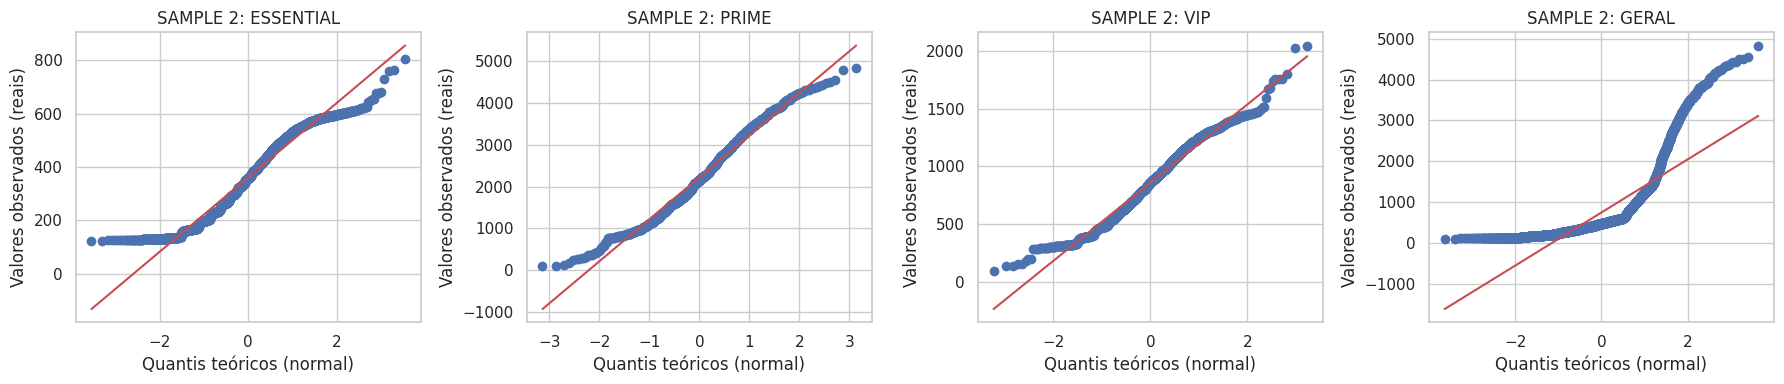

0 de 8 casos não rejeitam a normalidade a 5%.
Estatística AD média por grupo (quanto menor, mais próximo da normal):


,AD estatística
Grupo,
PRIME,5.20
VIP,8.61
ESSENTIAL,38.38
GERAL,585.03


Mais próximo da normal: PRIME. Mais distante: GERAL.


In [59]:
normalidade_s2 = AtividadeA1_3_1(sample2, "SAMPLE 2")

normalidade = pd.concat([normalidade_s1, normalidade_s2], ignore_index=True)
print(f"{int(normalidade['Normal (5%)'].sum())} de {len(normalidade)} casos não rejeitam a normalidade a 5%.")
media_ad = normalidade.groupby("Grupo")["AD estatística"].mean().sort_values()
print("Estatística AD média por grupo (quanto menor, mais próximo da normal):")
display(media_ad.round(2))
print(f"Mais próximo da normal: {media_ad.index[0]}. Mais distante: {media_ad.index[-1]}.")

**Conclusão da normalidade**

Pelo teste de Anderson-Darling, nenhum dos 8 casos (SAMPLE 1 e SAMPLE 2, por estrato e geral) é normal a 5%: em todos, a estatística AD ficou acima do valor crítico (cerca de 0,79). O estrato mais próximo da normal é o PRIME (estatística AD de 5,78 e 4,61, assimetria de 0,19 e 0,23 e curtose de -0,90 e -0,80 nas duas amostras). Sem os outliers, o ESSENTIAL e o VIP ficaram simétricos (assimetria entre 0,01 e 0,12), mas achatados (curtose perto de -1), por isso também rejeitam a normalidade (AD de 40,01 e 36,75 no ESSENTIAL e de 10,31 e 6,91 no VIP). O conjunto GERAL é o mais distante (AD de 589,41 e 580,64, assimetria de 2,40), porque mistura três estratos com níveis de gasto muito diferentes, o que aparece no gráfico Q-Q como uma curva em S. Por isso a independência e a distribuição são avaliadas com testes não paramétricos, e o teste de médias se apoia no tamanho grande das amostras (teorema central do limite).

#### A1.3.2: Teste de Independência

Nesta ETAPA, você deve fazer o **TESTE DE ANOVA (+ Gráfico Bootstrap) sobre Testes de Independência: p_value** sobre:

*   SAMPLE 1 e SAMPLE 2
*   RESPONDER: Qual o BEST FIT ?

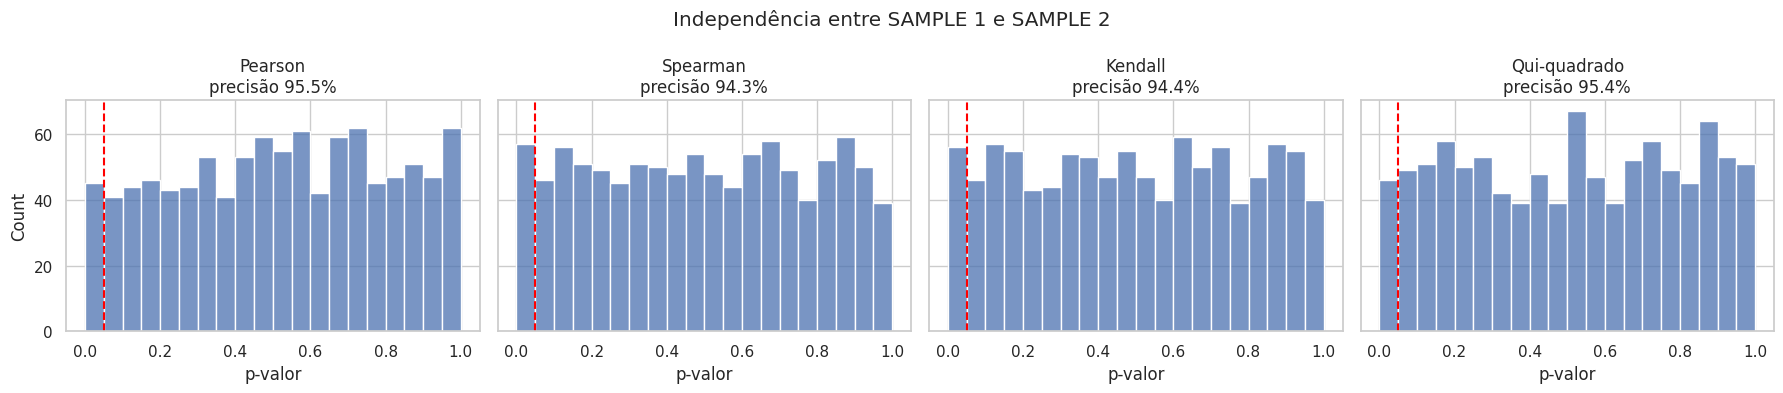

Melhor ajuste: Qui-quadrado com precisão de 95.4%


,Teste,Paramétrico,p-valor SAMPLE 1 x 2 (%),p mediano,p médio,"p 2,5%","p 97,5%",Precisão (%)
0,Pearson,True,7.7554,0.5297,0.5201,0.0278,0.9805,95.5
1,Spearman,False,6.8644,0.4945,0.4943,0.0200,0.9680,94.3
2,Kendall,False,6.7309,0.4916,0.4945,0.0200,0.9697,94.4
3,Qui-quadrado,False,35.6784,0.5188,0.5072,0.0277,0.9752,95.4


Conclusão: SAMPLE 1 e SAMPLE 2 são independentes. Melhor ajuste: Qui-quadrado, precisão de 95.4% em 1000 pares de amostras (faixa esperada se H0 for verdadeira: 93.6% a 96.3%).
No par sorteado, o p-valor foi de 35.68%, acima de 5%.


In [60]:
def AtividadeA1_3_2(normalidade, df=None, n=None, repeticoes=1000, alpha=0.05):
    """
    HELP:
    Atividade A1.3.2: teste de independência entre SAMPLE 1 e SAMPLE 2.

    Aplica Pearson, Spearman, Kendall e qui-quadrado nas duas amostras
    sorteadas (p-valor observado) e repete o sorteio de pares de amostras
    (bootstrap) para medir a precisão de cada teste. Se a normalidade geral
    foi rejeitada, só os testes não paramétricos concorrem ao melhor ajuste.

    Parâmetros
    ----------
    normalidade : pandas.DataFrame
        Resultado da Atividade A1.3.1 (SAMPLE 1 e SAMPLE 2).
    df : pandas.DataFrame, opcional
        Base de onde as amostras saem. Se vazia usa base_final.
    n : int, opcional
        Tamanho ideal. Se vazio usa n_ideal.
    repeticoes : int
        Repetições do bootstrap.
    alpha : float
        Nível de significância.

    Retorna
    -------
    dict
        resumo, melhor e pvalores.
    """
    df = base_final if df is None else df
    n = n_ideal if n is None else n
    normal_geral = bool(normalidade.query("Grupo == 'GERAL'")["Normal (5%)"].all())

    resumo, melhor, pvalores = executar_familia_testes(
        df, n, testes_independencia(), normal_geral,
        "Independência entre SAMPLE 1 e SAMPLE 2", alpha, repeticoes,
        x_obs=sample1[ALVO], y_obs=sample2[ALVO]
    )
    display(resumo.round(4))

    mantida = concluir_familia(melhor, repeticoes, alpha,
                               "são independentes", "não são independentes")
    return {"resumo": resumo, "melhor": melhor, "pvalores": pvalores, "mantida": mantida}


resultado_ind = AtividadeA1_3_2(normalidade)

**RESPONDER: SAMPLE 1 e SAMPLE 2 são INDEPENDENTES ???**

CONCLUIR / RESPONDER AQUI:
*   **Sim, SAMPLE 1 e SAMPLE 2 são independentes.** Em 1.000 pares de amostras sorteados (bootstrap), o melhor ajuste (qui-quadrado) não rejeitou a independência em 95,4% das vezes, dentro da faixa esperada quando a hipótese nula é verdadeira (93,6% a 96,3% para alpha de 5%). No par sorteado, o p-valor foi de 35,68%, acima de 5%.
*   Como a normalidade foi rejeitada, o melhor ajuste foi escolhido entre os testes não paramétricos (Spearman, Kendall e qui-quadrado). Nos outros testes a precisão foi de 95,5% no Pearson, 94,3% no Spearman e 94,4% no Kendall, e no par sorteado nenhum rejeitou a independência (p-valores de 7,76%, 6,86% e 6,73%). Os p-valores do bootstrap se espalham de forma quase uniforme entre 0 e 1, o comportamento esperado quando a hipótese nula é verdadeira.

#### A1.3.3: Teste de Distribuição

Nesta ETAPA, você deve fazer o **TESTE DE ANOVA (+ Gráfico Bootstrap) sobre Teste de Mesma Distribuição: p_value** sobre:

*   SAMPLE 1 e SAMPLE 2
*   RESPONDER: Qual o BEST FIT ?

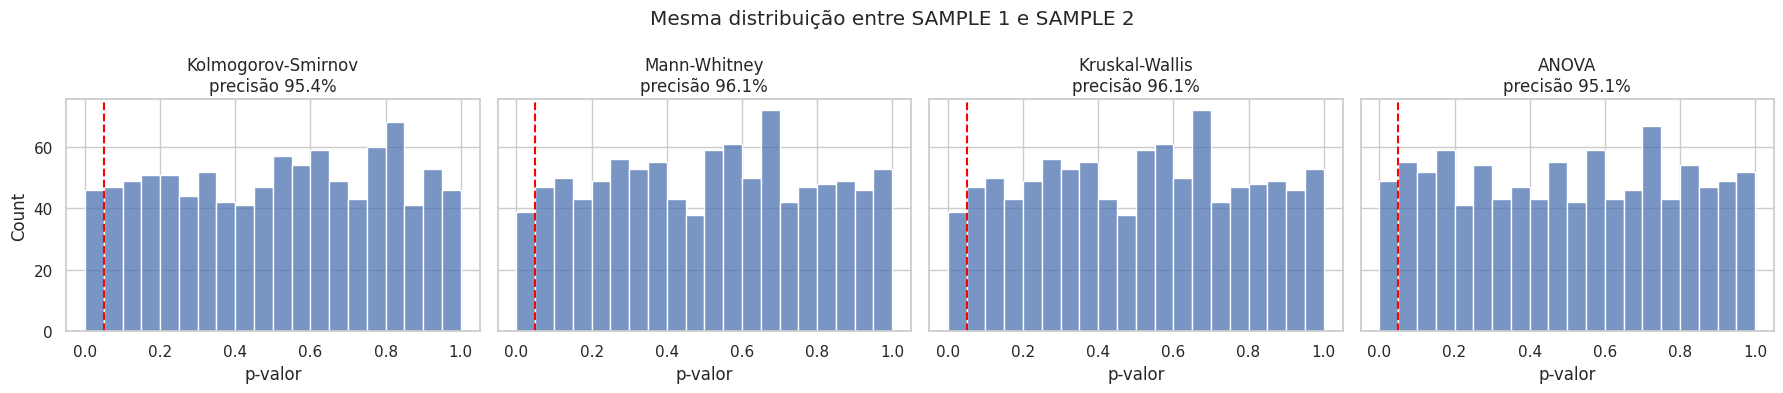

Melhor ajuste: Mann-Whitney com precisão de 96.1%


,Teste,Paramétrico,p-valor SAMPLE 1 x 2 (%),p mediano,p médio,"p 2,5%","p 97,5%",Precisão (%)
0,Kolmogorov-Smirnov,False,59.4006,0.5308,0.5094,0.0308,0.9748,95.4
1,Mann-Whitney,False,62.7042,0.5254,0.5085,0.0280,0.9724,96.1
2,Kruskal-Wallis,False,62.7040,0.5254,0.5085,0.0280,0.9724,96.1
3,ANOVA,True,45.3658,0.5021,0.4995,0.0269,0.9730,95.1


Conclusão: SAMPLE 1 e SAMPLE 2 têm a mesma distribuição. Melhor ajuste: Mann-Whitney, precisão de 96.1% em 1000 pares de amostras (faixa esperada se H0 for verdadeira: 93.6% a 96.3%).
No par sorteado, o p-valor foi de 62.70%, acima de 5%.


In [61]:
def AtividadeA1_3_3(normalidade, df=None, n=None, repeticoes=1000, alpha=0.05):
    """
    HELP:
    Atividade A1.3.3: teste de mesma distribuição entre SAMPLE 1 e SAMPLE 2.

    Aplica Kolmogorov-Smirnov, Mann-Whitney, Kruskal-Wallis e ANOVA nas duas
    amostras sorteadas e em cada par de amostras do bootstrap. A precisão em %
    é a porcentagem de repetições em que a hipótese de mesma distribuição não
    foi rejeitada.

    Parâmetros
    ----------
    normalidade : pandas.DataFrame
        Resultado da Atividade A1.3.1 (SAMPLE 1 e SAMPLE 2).
    df : pandas.DataFrame, opcional
        Base de onde as amostras saem. Se vazia usa base_final.
    n : int, opcional
        Tamanho ideal. Se vazio usa n_ideal.
    repeticoes : int
        Repetições do bootstrap.
    alpha : float
        Nível de significância.

    Retorna
    -------
    dict
        resumo, melhor e pvalores.
    """
    df = base_final if df is None else df
    n = n_ideal if n is None else n
    normal_geral = bool(normalidade.query("Grupo == 'GERAL'")["Normal (5%)"].all())

    resumo, melhor, pvalores = executar_familia_testes(
        df, n, testes_distribuicao(), normal_geral,
        "Mesma distribuição entre SAMPLE 1 e SAMPLE 2", alpha, repeticoes,
        x_obs=sample1[ALVO], y_obs=sample2[ALVO]
    )
    display(resumo.round(4))

    mantida = concluir_familia(melhor, repeticoes, alpha,
                               "têm a mesma distribuição", "têm distribuições diferentes")
    return {"resumo": resumo, "melhor": melhor, "pvalores": pvalores, "mantida": mantida}


resultado_dist = AtividadeA1_3_3(normalidade)

**RESPONDER: SAMPLE 1 e SAMPLE 2 tem a MESMA DISTRIBUIÇÃO DOS DADOS ???**

CONCLUIR / RESPONDER AQUI:
*   **Sim, SAMPLE 1 e SAMPLE 2 têm a mesma distribuição, com precisão de 96,1%** (melhor ajuste: Mann-Whitney), dentro da faixa esperada quando a hipótese nula é verdadeira (93,6% a 96,3% em 1.000 pares de amostras, alpha de 5%). No par sorteado, o p-valor foi de 62,70%, acima de 5%.
*   Nos 1.000 pares, a mesma distribuição não foi rejeitada em 95,4% (Kolmogorov-Smirnov), 96,1% (Mann-Whitney), 96,1% (Kruskal-Wallis) e 95,1% (ANOVA) das vezes. Mann-Whitney e Kruskal-Wallis empatam porque, com duas amostras, os dois testes são equivalentes.

#### A1.3.4: Teste das Médias Amostrais

Nesta ETAPA, você deve fazer o **TESTE DE ANOVA (+ Gráfico Bootstrap) sobre Teste das Médias Amostrais: p_value** sobre:

*   SAMPLE 1 e SAMPLE 2
*   RESPONDER: Qual o BEST FIT ?

Média SAMPLE 1: R$ 754.74 | Média SAMPLE 2: R$ 743.31 | diferença: R$ 11.44


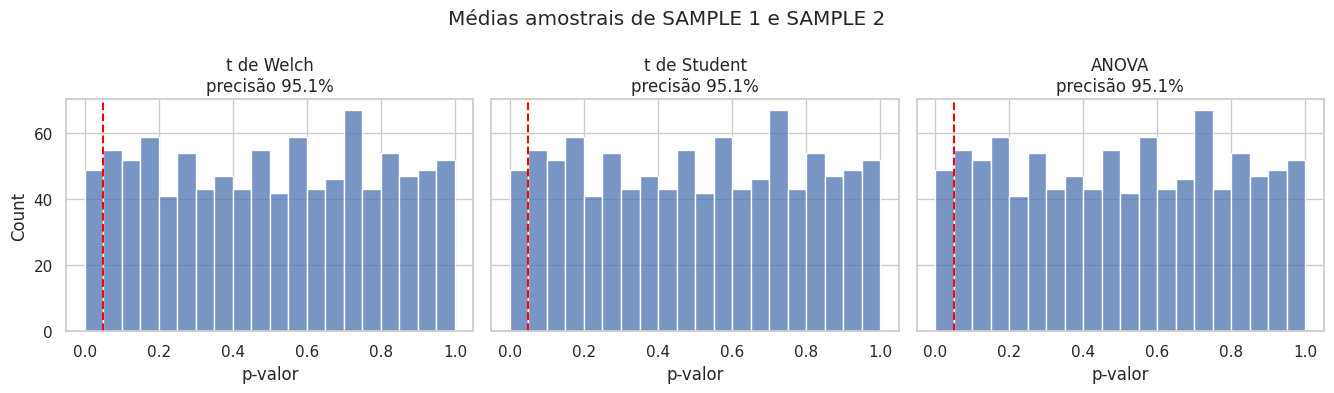

Melhor ajuste: t de Welch com precisão de 95.1%


,Teste,Paramétrico,p-valor SAMPLE 1 x 2 (%),p mediano,p médio,"p 2,5%","p 97,5%",Precisão (%)
0,t de Welch,True,45.3658,0.5021,0.4995,0.0269,0.973,95.1
1,t de Student,True,45.3658,0.5021,0.4995,0.0269,0.973,95.1
2,ANOVA,True,45.3658,0.5021,0.4995,0.0269,0.973,95.1


Conclusão: SAMPLE 1 e SAMPLE 2 têm médias iguais. Melhor ajuste: t de Welch, precisão de 95.1% em 1000 pares de amostras (faixa esperada se H0 for verdadeira: 93.6% a 96.3%).
No par sorteado, o p-valor foi de 45.37%, acima de 5%.


In [62]:
def AtividadeA1_3_4(df=None, n=None, repeticoes=1000, alpha=0.05):
    """
    HELP:
    Atividade A1.3.4: teste das médias amostrais entre SAMPLE 1 e SAMPLE 2.

    Mostra a média de cada amostra e aplica t de Welch, t de Student e ANOVA
    nas duas amostras sorteadas e no bootstrap. Com n grande o teorema central
    do limite sustenta os testes de médias mesmo sem normalidade, por isso
    todos concorrem ao melhor ajuste.

    Parâmetros
    ----------
    df : pandas.DataFrame, opcional
        Base de onde as amostras saem. Se vazia usa base_final.
    n : int, opcional
        Tamanho ideal. Se vazio usa n_ideal.
    repeticoes : int
        Repetições do bootstrap.
    alpha : float
        Nível de significância.

    Retorna
    -------
    dict
        resumo, melhor, pvalores e as médias das duas amostras.
    """
    df = base_final if df is None else df
    n = n_ideal if n is None else n

    media_1, media_2 = sample1[ALVO].mean(), sample2[ALVO].mean()
    print(f"Média SAMPLE 1: R$ {media_1:.2f} | Média SAMPLE 2: R$ {media_2:.2f} | "
          f"diferença: R$ {media_1 - media_2:.2f}")

    resumo, melhor, pvalores = executar_familia_testes(
        df, n, testes_medias(), True,
        "Médias amostrais de SAMPLE 1 e SAMPLE 2", alpha, repeticoes,
        x_obs=sample1[ALVO], y_obs=sample2[ALVO]
    )
    display(resumo.round(4))

    mantida = concluir_familia(melhor, repeticoes, alpha,
                               "têm médias iguais", "têm médias diferentes")
    return {"resumo": resumo, "melhor": melhor, "pvalores": pvalores, "mantida": mantida,
            "media_1": media_1, "media_2": media_2}


resultado_med = AtividadeA1_3_4()

**RESPONDER: SAMPLE 1 e SAMPLE 2 tem as MESMAS MÉDIAS AMOSTRAIS ???**

CONCLUIR / RESPONDER AQUI:
*   **Sim, SAMPLE 1 e SAMPLE 2 têm a mesma média**: 754,74 reais na SAMPLE 1 e 743,31 reais na SAMPLE 2 (diferença de 11,44 reais). No melhor ajuste (t de Welch), a igualdade das médias não foi rejeitada em 95,1% dos 1.000 pares de amostras, dentro da faixa esperada (93,6% a 96,3%); no par sorteado, o p-valor foi de 45,37%, acima de 5%.
*   t de Welch, t de Student e ANOVA dão o mesmo resultado porque as duas amostras têm o mesmo tamanho; o t de Welch foi o escolhido por não exigir variâncias iguais. Mesmo sem normalidade, o teste é válido pelo teorema central do limite, já que cada amostra tem 5.400 notas.

##Atividade A2 ([Link](https://colab.research.google.com/drive/1w-72bl_qBnGIR8y9zcGYNcpar9b2JdwA?usp=sharing)): Estatística descritiva

###Atividade A2.1: Analisar as variáveis Quantitativas

Estatística descritiva das variáveis quantitativas:


,mean,std,min,25%,50%,75%,max,amplitude,moda,assimetria,CV (%)
DEPENDENTES,1.05,0.95,0.00,0.00,1.00,1.00,4.00,4.00,1.00,1.22,90.19
RENDA BRUTO (R$),6846.41,6338.61,1898.64,3226.72,3316.06,7785.33,29171.26,27272.62,3241.75,1.81,92.58
NOTA DE SATISFAÇÃO (%),68.99,1.42,68.68,68.68,68.68,68.68,86.05,17.37,68.68,5.75,2.05
MEAN: alcohol,12.98,0.82,9.55,12.43,12.99,13.55,15.89,6.34,13.15,-0.05,6.31
MEAN: malic_acid,2.35,1.13,-1.65,1.56,2.37,3.13,6.30,7.95,2.42,-0.03,48.23
MEAN: ash,2.37,0.27,1.37,2.19,2.36,2.55,3.34,1.96,2.38,0.03,11.32
MEAN: alcalinity_of_ash,19.46,3.36,7.99,17.21,19.49,21.67,30.83,22.85,17.09,0.00,17.29
MEAN: magnesium,99.73,14.06,51.06,89.98,99.86,109.42,150.17,99.11,92.41,0.02,14.10
MEAN: total_phenols,2.29,0.62,0.09,1.87,2.29,2.70,4.49,4.40,2.27,0.00,27.26
MEAN: flavanoids,2.02,0.98,-1.45,1.37,2.02,2.71,5.27,6.72,1.83,-0.07,48.79


TOTAL (R$) por tipo de conta:


,n,Média,Mediana,Desvio padrão,Mínimo,Máximo,CV (%)
TIPO DA CONTA,,,,,,,
ESSENTIAL,3459,362.39,365.21,142.30,119.21,865.81,39.27
PRIME,804,2271.83,2194.35,1039.27,80.95,4760.16,45.75
VIP,1137,875.60,877.84,348.92,229.83,2059.31,39.85


RENDA BRUTO (R$) por tipo de conta:


,n,Média,Mediana,Desvio padrão,Mínimo,Máximo,CV (%)
TIPO DA CONTA,,,,,,,
ESSENTIAL,3459,3284.34,3250.01,557.60,2233.68,16009.62,16.98
PRIME,804,20634.87,21321.20,4390.99,1973.91,29171.26,21.28
VIP,1137,7932.88,7781.05,1414.85,1898.64,20654.43,17.84


NOTA DE SATISFAÇÃO (%) por tipo de conta:


,n,Média,Mediana,Desvio padrão,Mínimo,Máximo,CV (%)
TIPO DA CONTA,,,,,,,
ESSENTIAL,3459,68.68,68.68,0.00,68.68,68.68,0.00
PRIME,804,70.74,68.68,3.14,68.68,86.05,4.45
VIP,1137,68.68,68.68,0.00,68.68,68.68,0.00


Qualidade dos dados:


,Valores negativos,Negativos (%),No valor mais frequente (%)
DEPENDENTES,0,0.00,54.13
RENDA BRUTO (R$),0,0.00,0.07
NOTA DE SATISFAÇÃO (%),0,0.00,92.89
MEAN: alcohol,0,0.00,0.80
MEAN: malic_acid,102,1.89,0.57
MEAN: ash,0,0.00,1.76
MEAN: alcalinity_of_ash,0,0.00,0.24
MEAN: magnesium,0,0.00,0.13
MEAN: total_phenols,0,0.00,1.04
MEAN: flavanoids,102,1.89,0.63


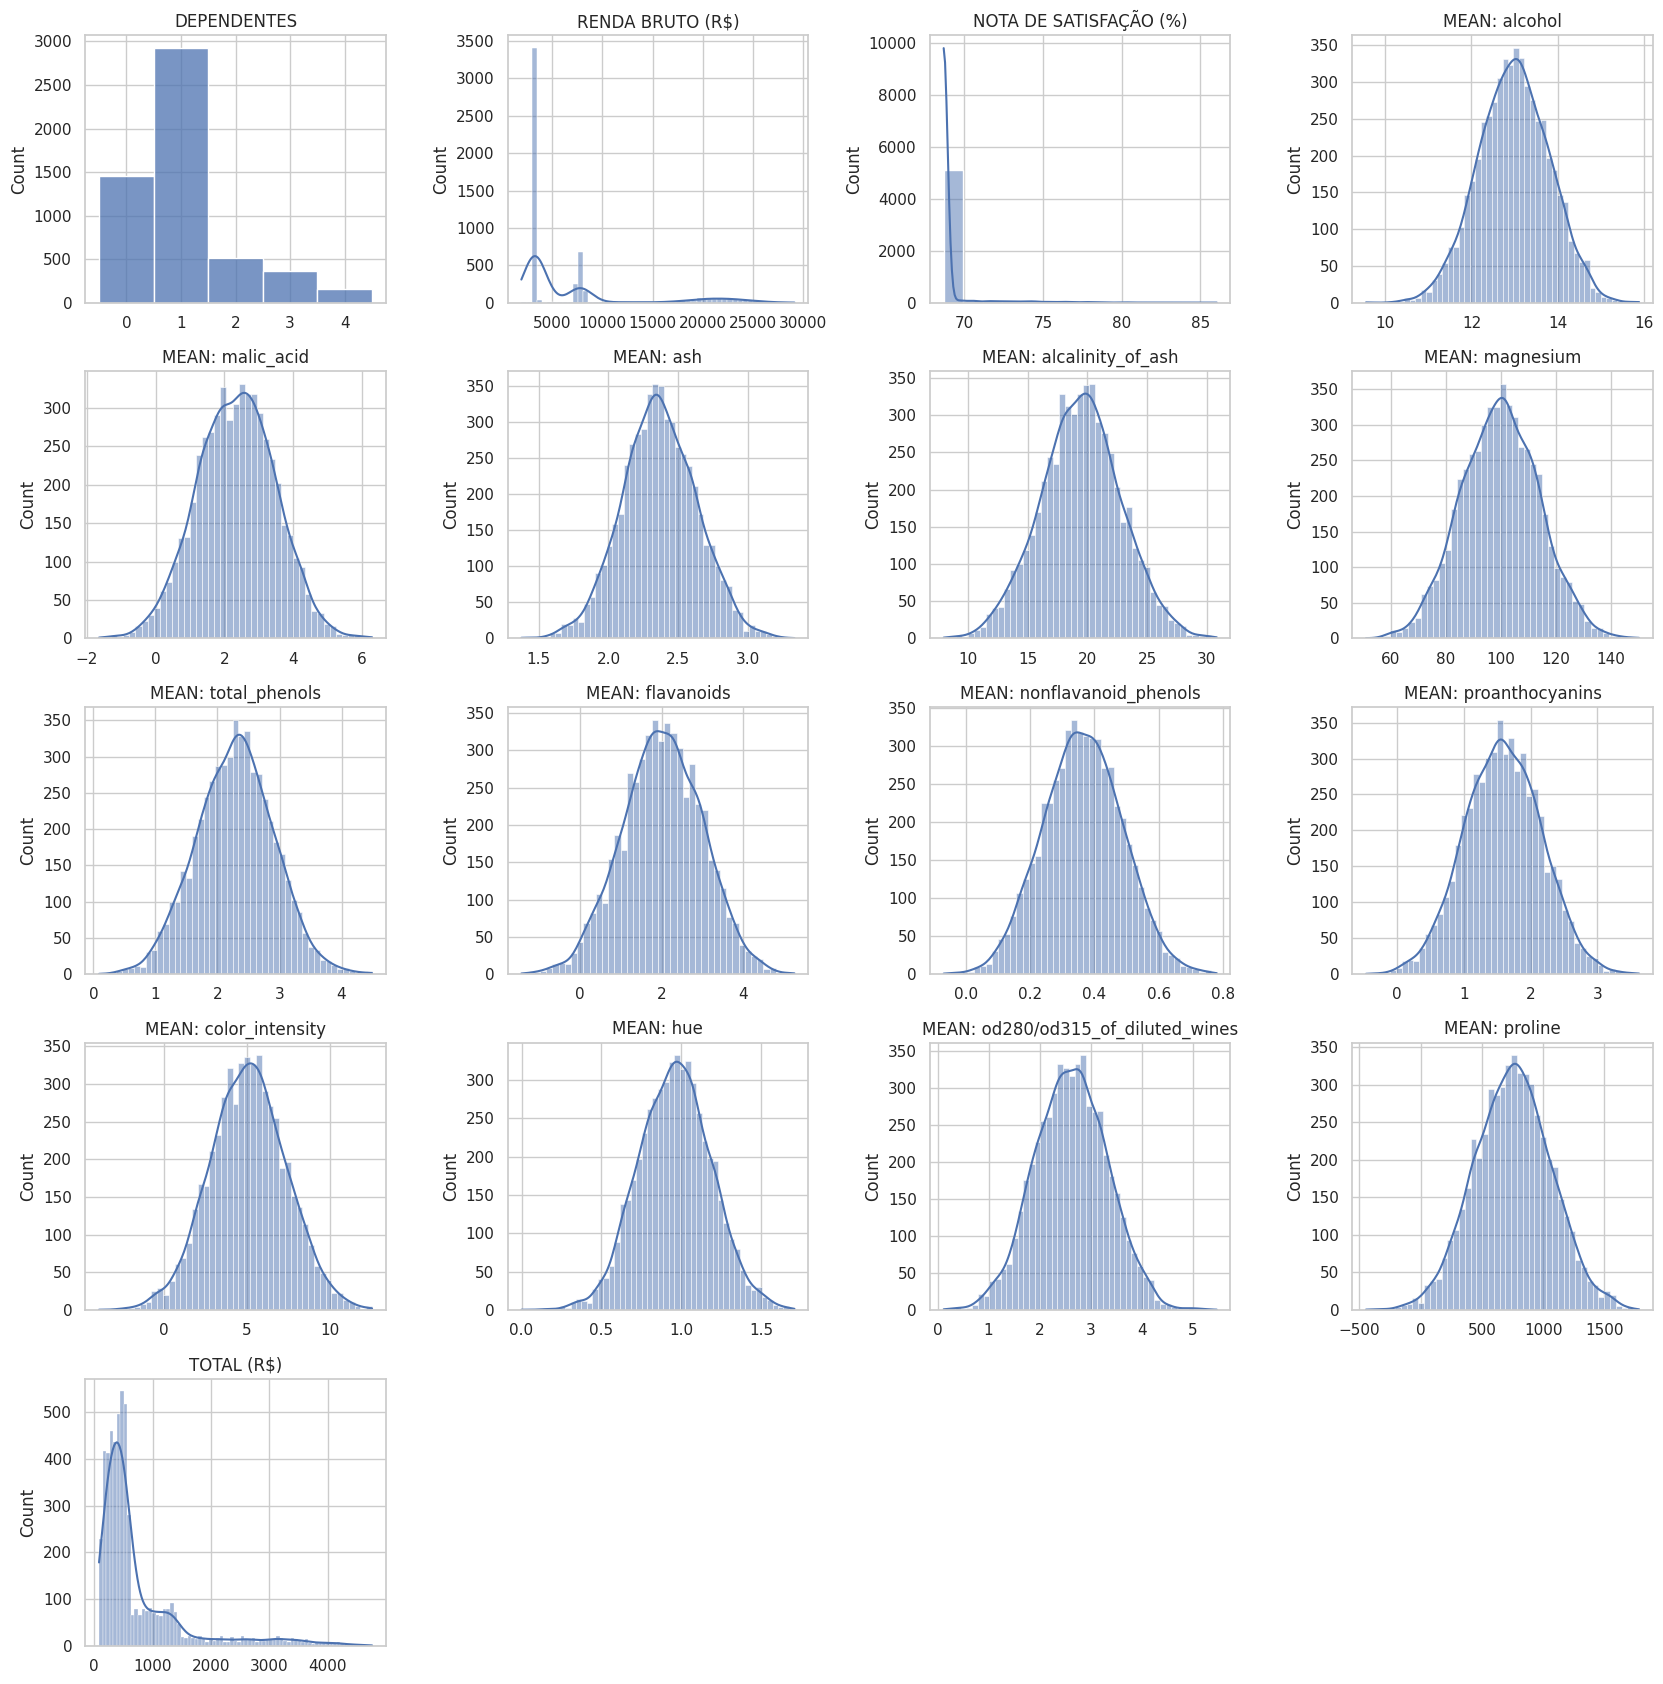

In [63]:
def descritiva_quantitativas(df):
    """
    Monta a tabela de estatística descritiva das variáveis quantitativas.

    Inclui média, desvio padrão, quartis, amplitude, moda, assimetria e
    coeficiente de variação.

    Parâmetros
    ----------
    df : pandas.DataFrame
        Amostra a ser descrita.

    Retorna
    -------
    pandas.DataFrame
        Uma linha por variável quantitativa.
    """
    numericas = df.select_dtypes(include="number").drop(columns=["NOTA FISCAL"], errors="ignore")
    tabela = numericas.describe().T.drop(columns="count")
    tabela["amplitude"] = tabela["max"] - tabela["min"]
    tabela["moda"] = numericas.apply(lambda c: c.round(2).mode().iloc[0])
    tabela["assimetria"] = numericas.skew()
    tabela["CV (%)"] = 100 * numericas.std() / numericas.mean()
    return tabela.round(2)



def resumo_por_grupo(df, coluna_valor, coluna_grupo=ESTRATO):
    """
    Resume uma variável quantitativa por grupo.

    Parâmetros
    ----------
    df : pandas.DataFrame
        Amostra.
    coluna_valor : str
        Variável quantitativa.
    coluna_grupo : str
        Coluna que define os grupos (padrão: TIPO DA CONTA).

    Retorna
    -------
    pandas.DataFrame
        n, média, mediana, desvio padrão, mínimo, máximo e CV (%) por grupo.
    """
    grupos = df.groupby(coluna_grupo)[coluna_valor]
    tabela = pd.DataFrame({
        "n": grupos.size(),
        "Média": grupos.mean(),
        "Mediana": grupos.median(),
        "Desvio padrão": grupos.std(),
        "Mínimo": grupos.min(),
        "Máximo": grupos.max(),
    })
    tabela["CV (%)"] = 100 * tabela["Desvio padrão"] / tabela["Média"]
    return tabela.round(2)


def checar_qualidade(df):
    """
    Aponta problemas de qualidade nas variáveis quantitativas.

    Conta os valores negativos (impossíveis para medidas químicas, renda e
    gasto) e mede a concentração no valor mais frequente, que revela
    variáveis quase constantes.

    Parâmetros
    ----------
    df : pandas.DataFrame
        Amostra.

    Retorna
    -------
    pandas.DataFrame
        Valores negativos, percentual de negativos e percentual no valor mais
        frequente de cada variável.
    """
    numericas = df.select_dtypes(include="number").drop(columns=["NOTA FISCAL"], errors="ignore")
    tabela = pd.DataFrame({
        "Valores negativos": (numericas < 0).sum(),
        "Negativos (%)": 100 * (numericas < 0).mean(),
        "No valor mais frequente (%)": numericas.apply(
            lambda c: 100 * c.round(2).value_counts(normalize=True).iloc[0]
        ),
    })
    return tabela.round(2)


def grafico_histogramas(df, colunas, colunas_por_linha=4):
    """
    Desenha um histograma para cada coluna informada.

    Variáveis contínuas recebem a curva de densidade; variáveis discretas com
    poucos valores (como DEPENDENTES) são desenhadas com uma barra por valor.

    Parâmetros
    ----------
    df : pandas.DataFrame
        Amostra.
    colunas : list of str
        Variáveis quantitativas a desenhar.
    colunas_por_linha : int
        Quantidade de gráficos por linha.
    """
    linhas = int(np.ceil(len(colunas) / colunas_por_linha))
    fig, eixos = plt.subplots(linhas, colunas_por_linha,
                              figsize=(4.2 * colunas_por_linha, 3.4 * linhas))
    eixos = np.atleast_1d(eixos).ravel()

    for eixo, coluna in zip(eixos, colunas):
        if df[coluna].nunique() <= 10:
            sns.histplot(df[coluna], discrete=True, ax=eixo)
        else:
            sns.histplot(df[coluna], kde=True, ax=eixo)
        eixo.set_title(coluna)
        eixo.set_xlabel("")

    for eixo in eixos[len(colunas):]:
        eixo.axis("off")

    plt.tight_layout()
    plt.show()


def AtividadeA2_1(amostra):
    """
    HELP:
    Atividade A2.1: estatística descritiva das variáveis quantitativas.

    Mostra a tabela descritiva (média, quartis, amplitude, moda, assimetria e
    coeficiente de variação), o TOTAL (R$), a RENDA BRUTO (R$) e a NOTA DE
    SATISFAÇÃO (%) por tipo de conta, a checagem de qualidade dos dados e os
    histogramas de cada variável.

    Parâmetros
    ----------
    amostra : pandas.DataFrame
        Amostra do tamanho ideal.
    """
    print("Estatística descritiva das variáveis quantitativas:")
    display(descritiva_quantitativas(amostra))

    for coluna in [ALVO, "RENDA BRUTO (R$)", "NOTA DE SATISFAÇÃO (%)"]:
        print(f"{coluna} por tipo de conta:")
        display(resumo_por_grupo(amostra, coluna))

    print("Qualidade dos dados:")
    display(checar_qualidade(amostra))

    colunas = amostra.select_dtypes(include="number").drop(columns=["NOTA FISCAL"], errors="ignore").columns.tolist()
    grafico_histogramas(amostra, colunas)


amostra_ideal = sample1.copy()
AtividadeA2_1(amostra_ideal)

**Síntese das variáveis quantitativas**

*   **`TOTAL (R$)`**: média de 754,74 reais e mediana de 472,38 reais, com assimetria de 2,40 e coeficiente de variação de 106,3%. O gasto cresce com o tipo de conta: média de 362,39 reais no ESSENTIAL, 875,60 reais no VIP e 2.271,83 reais no PRIME.
*   **`RENDA BRUTO (R$)`**: o histograma tem três grupos bem separados, que correspondem aos tipos de conta (renda média de 3.284,34 reais no ESSENTIAL, 7.932,88 reais no VIP e 20.634,87 reais no PRIME). É a variável com maior potencial para explicar o gasto e o tipo de conta na Parte 2.
*   **NOTA DE SATISFAÇÃO (%)**: 92,9% das notas têm o mesmo valor (68,68%). A nota só varia entre os clientes PRIME (média de 70,74% e máximo de 86,05%); no ESSENTIAL e no VIP ela é constante.
*   **DEPENDENTES**: de 0 a 4, com moda de 1 dependente (54,1% das notas) e média de 1,05.
*   **Variáveis do vinho (MEAN:)**: distribuição próxima da normal (assimetria perto de zero), mas 7 das 13 variáveis têm valores negativos, como malic_acid e flavanoids (1,89% das notas cada), color_intensity (1,65%) e proline (0,81%), o que é impossível para medidas químicas. É um problema de qualidade dos dados a tratar antes dos modelos da Parte 2.
*   A carga não tem valores ausentes nem números de nota fiscal repetidos.

###Atividade A2.2: Analisar as variáveis Qualitativas

,Frequência,Percentual (%),Acumulado (%),Gasto médio (R$),Gasto mediano (R$)
REGIÃO,,,,,
SUDESTE,3630,67.22,67.22,750.92,467.84
SUL,867,16.06,83.28,744.95,478.49
CENTRO-OESTE,479,8.87,92.15,773.92,485.37
NORDESTE,320,5.93,98.07,756.04,476.88
NORTE,104,1.93,100.00,877.43,506.84


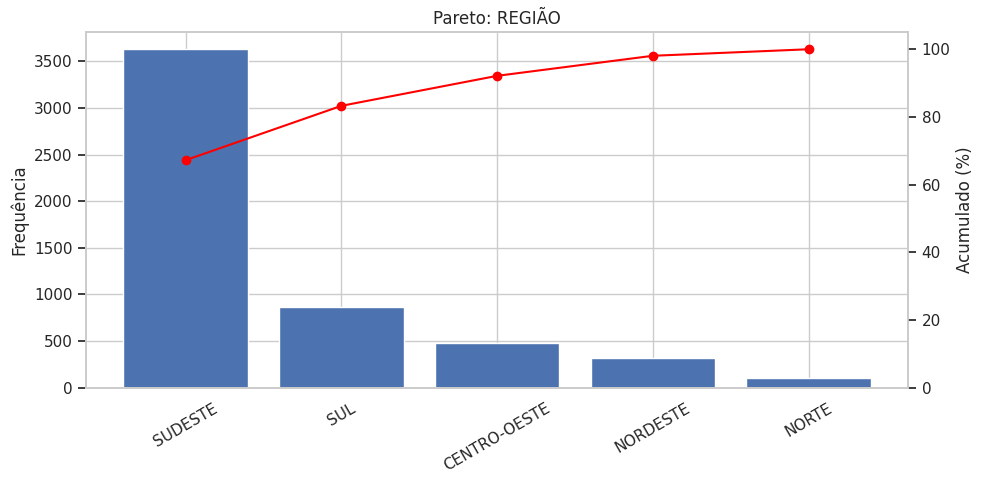

,Frequência,Percentual (%),Acumulado (%),Gasto médio (R$),Gasto mediano (R$)
SEXO,,,,,
MASCULINO,4691,86.87,86.87,755.12,472.84
FEMININO,709,13.13,100.00,752.27,468.95


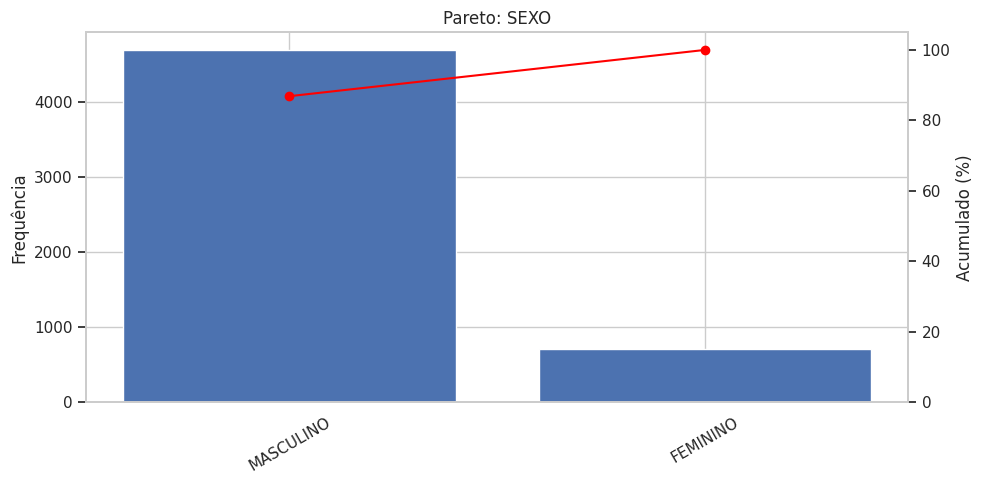

,Frequência,Percentual (%),Acumulado (%),Gasto médio (R$),Gasto mediano (R$)
ESTADO CIVIL,,,,,
CASADO,2919,54.06,54.06,755.99,472.84
SOLTEIRO,2071,38.35,92.41,754.24,468.95
DESQUITADO(A) / VIÚVO(A),410,7.59,100.00,748.42,483.10


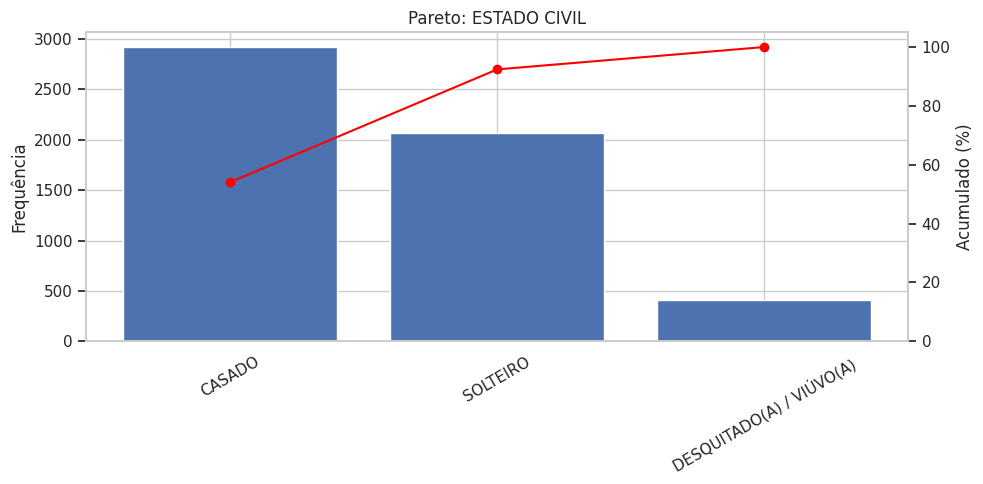

,Frequência,Percentual (%),Acumulado (%),Gasto médio (R$),Gasto mediano (R$)
TIPO DA CONTA,,,,,
ESSENTIAL,3459,64.06,64.06,362.39,365.21
VIP,1137,21.06,85.11,875.60,877.84
PRIME,804,14.89,100.00,2271.83,2194.35


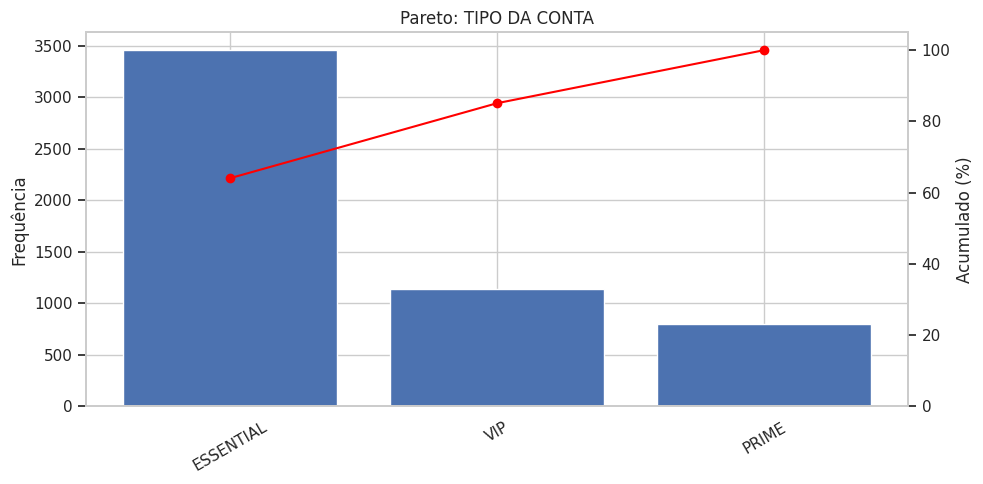

In [64]:
def frequencias_qualitativas(df, colunas, value_column=ALVO):
    """
    Calcula frequência absoluta, relativa e acumulada de variáveis qualitativas.

    Cada tabela traz também o gasto médio e o gasto mediano de cada
    categoria, para relacionar a variável com o TOTAL (R$).

    Parâmetros
    ----------
    df : pandas.DataFrame
        Amostra.
    colunas : list of str
        Variáveis qualitativas.
    value_column : str
        Variável alvo.

    Retorna
    -------
    dict
        Coluna -> DataFrame com Frequência, Percentual (%), Acumulado (%),
        Gasto médio (R$) e Gasto mediano (R$).
    """
    tabelas = {}
    for coluna in colunas:
        freq = df[coluna].value_counts()
        tabela = pd.DataFrame({"Frequência": freq})
        tabela["Percentual (%)"] = 100 * freq / freq.sum()
        tabela["Acumulado (%)"] = tabela["Percentual (%)"].cumsum()
        tabela["Gasto médio (R$)"] = df.groupby(coluna)[value_column].mean()
        tabela["Gasto mediano (R$)"] = df.groupby(coluna)[value_column].median()
        tabelas[coluna] = tabela.round(2)
    return tabelas


def grafico_pareto(serie, titulo=""):
    """
    Desenha o gráfico de Pareto de uma variável qualitativa.

    Parâmetros
    ----------
    serie : pandas.Series
        Variável qualitativa.
    titulo : str
        Título do gráfico.
    """
    freq = serie.value_counts()
    acumulado = 100 * freq.cumsum() / freq.sum()

    fig, eixo = plt.subplots(figsize=(10, 5))
    eixo.bar(freq.index.astype(str), freq.values)
    eixo.set_ylabel("Frequência")
    eixo.tick_params(axis="x", rotation=30)

    eixo2 = eixo.twinx()
    eixo2.plot(freq.index.astype(str), acumulado.values, color="red", marker="o")
    eixo2.set_ylim(0, 105)
    eixo2.set_ylabel("Acumulado (%)")
    eixo2.grid(False)

    plt.title(titulo)
    plt.tight_layout()
    plt.show()



def AtividadeA2_2(amostra, colunas=("REGIÃO", "SEXO", "ESTADO CIVIL", "TIPO DA CONTA")):
    """
    HELP:
    Atividade A2.2: análise das variáveis qualitativas.

    Mostra a tabela de frequências (absoluta, relativa e acumulada) com o gasto
    médio de cada categoria e o gráfico de Pareto de cada variável.

    Parâmetros
    ----------
    amostra : pandas.DataFrame
        Amostra do tamanho ideal.
    colunas : tuple of str
        Variáveis qualitativas analisadas.
    """
    tabelas = frequencias_qualitativas(amostra, list(colunas))
    for coluna, tabela in tabelas.items():
        display(tabela)
        grafico_pareto(amostra[coluna], f"Pareto: {coluna}")


AtividadeA2_2(amostra_ideal)

**Síntese das variáveis qualitativas**

*   **REGIÃO**: 67,2% Sudeste, 16,1% Sul, 8,9% Centro-Oeste, 5,9% Nordeste e 1,9% Norte.
*   **SEXO**: 86,9% masculino e 13,1% feminino.
*   **ESTADO CIVIL**: 54,1% casados, 38,4% solteiros e 7,6% desquitados ou viúvos.
*   **TIPO DA CONTA**: 64,1% ESSENTIAL, 21,1% VIP e 14,9% PRIME, praticamente os pesos da base sem outliers (63,8%, 21,1% e 15,1%), o que confirma que a amostra preserva a estratificação.
*   **Gasto por categoria**: o gasto médio quase não muda por sexo (752,27 reais entre as mulheres e 755,12 reais entre os homens) nem por estado civil (de 748,42 reais entre os desquitados ou viúvos a 755,99 reais entre os casados). Por região fica entre 744,95 reais no Sul e 773,92 reais no Centro-Oeste; o Norte aparece mais alto (877,43 reais), mas com apenas 104 notas. A grande diferença está no tipo de conta: de 362,39 reais no ESSENTIAL a 2.271,83 reais no PRIME.

##Atividade A3: Resultado da Pesquisa de Satisfação

Fazer o resultado da Pesquisa de satisfação do cliente em porcentagem (%):
* Geral
* Por Sexo

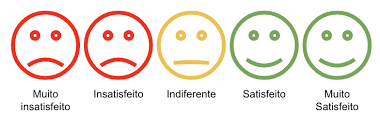

###Atividade A3.1: Discretizar a Variável Qualitativa (OPINIÃO DO CLIENTE)

In [65]:
NIVEIS_SATISFACAO = ["Muito insatisfeito", "Insatisfeito", "Indiferente", "Satisfeito", "Muito satisfeito"]

REGRAS_SATISFACAO = [
    ("Muito insatisfeito", ["não gostei", "deixou a desejar", "faltou", "atrasad", "péssim", "horrível",
                            "não recomendo", "nunca mais", "decepcion", "ruim"]),
    ("Insatisfeito", ["insatisf", "regular", "comum", "aceitável", "esperava mais", "razoável",
                      "poderia melhorar", "margem de melhora", "não atendeu", "nada demais"]),
    ("Indiferente", ["nada digno", "indiferente", "sem opinião", "não tenho muito", "neutr"]),
    ("Muito satisfeito", ["excelente", "perfeito", "impecável", "superou", "ótimo", "maravilh",
                          "adorei", "top demais", "recomendo muito"]),
    ("Satisfeito", ["recomendo", "satisfeito", "gostei", "boa e rápida", "funcionou bem",
                    "eficiente"]),
]


def classificar_opiniao(texto):
    """
    Converte a opinião do cliente em um dos 5 níveis da escala de satisfação.

    A escala segue a figura do enunciado: Muito insatisfeito, Insatisfeito,
    Indiferente, Satisfeito e Muito satisfeito. As regras são verificadas da
    mais negativa para a mais positiva, para que "insatisfeito" não seja lido
    como "satisfeito" nem "não recomendo" como "recomendo".

    Critério: reclamação direta (atraso, falta de qualidade, "deixou a
    desejar") é Muito insatisfeito; avaliação morna com ressalva ("regular",
    "comum", "aceitável", "esperava mais") é Insatisfeito; ausência de opinião
    é Indiferente; elogio simples é Satisfeito; elogio enfático ("excelente",
    "perfeito", "impecável", "superou expectativas") é Muito satisfeito.

    Parâmetros
    ----------
    texto : str
        Opinião do cliente.

    Retorna
    -------
    str
        Nível da escala ou NÃO CLASSIFICADA.
    """
    t = str(texto).lower()
    for nivel, chaves in REGRAS_SATISFACAO:
        if any(chave in t for chave in chaves):
            return nivel
    return "NÃO CLASSIFICADA"


def tabela_classificacao(df, coluna="OPINIÃO DO CLIENTE"):
    """
    Lista cada frase distinta com a quantidade de notas e o nível atribuído.

    Parâmetros
    ----------
    df : pandas.DataFrame
        Base ou amostra.
    coluna : str
        Coluna com a opinião do cliente.

    Retorna
    -------
    pandas.DataFrame
        Frase, notas, nível e posição na escala (1 a 5).
    """
    contagem = df[coluna].value_counts()
    tabela = pd.DataFrame({"Notas": contagem})
    tabela["Nível"] = [classificar_opiniao(frase) for frase in tabela.index]
    tabela["Escala (1 a 5)"] = tabela["Nível"].map(
        {nivel: i + 1 for i, nivel in enumerate(NIVEIS_SATISFACAO)}
    )
    return tabela.sort_values(["Escala (1 a 5)", "Notas"], ascending=[False, False])


def AtividadeA3_1(amostra, base=None):
    """
    HELP:
    Atividade A3.1: discretiza a variável qualitativa OPINIÃO DO CLIENTE.

    Converte cada opinião em um dos 5 níveis da escala de satisfação do
    enunciado e cria as colunas SATISFAÇÃO (texto) e SATISFAÇÃO (1 a 5).
    Mostra a classificação frase a frase para conferência; se a base for
    informada, a conferência cobre todas as frases da base.

    Parâmetros
    ----------
    amostra : pandas.DataFrame
        Amostra do tamanho ideal.
    base : pandas.DataFrame, opcional
        Base completa, usada só na tabela de conferência.

    Retorna
    -------
    pandas.DataFrame
        Cópia da amostra com as colunas novas.
    """
    print("Conferência da discretização, frase a frase:")
    display(tabela_classificacao(amostra if base is None else base))

    amostra = amostra.copy()
    amostra["SATISFAÇÃO"] = amostra["OPINIÃO DO CLIENTE"].apply(classificar_opiniao)
    amostra["SATISFAÇÃO (1 a 5)"] = amostra["SATISFAÇÃO"].map(
        {nivel: i + 1 for i, nivel in enumerate(NIVEIS_SATISFACAO)}
    )

    sem_classe = int((amostra["SATISFAÇÃO"] == "NÃO CLASSIFICADA").sum())
    if sem_classe:
        print(f"Atenção: {sem_classe} notas sem classe. Inclua essas frases em REGRAS_SATISFACAO.")
    else:
        print("Todas as opiniões da amostra foram classificadas.")

    contagem = amostra["SATISFAÇÃO"].value_counts().reindex(NIVEIS_SATISFACAO, fill_value=0)
    display(contagem.rename("Notas"))
    return amostra


amostra_ideal = AtividadeA3_1(amostra_ideal, base=base_final)

Conferência da discretização, frase a frase:


,Notas,Nível,Escala (1 a 5)
OPINIÃO DO CLIENTE,,,
"Serviço impecável, adorei o clube: UVVine",6746,Muito satisfeito,5
Superou expectativas o atendimento na UVVine,6696,Muito satisfeito,5
Ótimo! Tudo ocorreu maravilhosamente bem com a UVVine,6659,Muito satisfeito,5
"Excelente experiência, recomendo muito a UVVine",6564,Muito satisfeito,5
"Produto perfeito, chegou antes do prazo de previsão. Top demais a UVVine",6558,Muito satisfeito,5
Entrega foi boa e rápida na UVVine,170775,Satisfeito,4
Funcionou bem e me atendeu no prazo certo a UVVine,170702,Satisfeito,4
Fiquei satisfeito com o serviço da UVVine,170530,Satisfeito,4
"Serviço eficiente, recomendo o clube: UVVine",170214,Satisfeito,4


Todas as opiniões da amostra foram classificadas.


,Notas
SATISFAÇÃO,
Muito insatisfeito,51
Insatisfeito,223
Indiferente,768
Satisfeito,4199
Muito satisfeito,159


###Atividade A3.2: Análise Bootstrap do resultado da Pesquisa de Satisfação

,Recorte,Nível,n,Percentual (%),IC inferior (%),IC superior (%),Erro-padrão (p.p.)
0,GERAL,Muito insatisfeito,5400,0.94,0.69,1.20,0.13
1,GERAL,Insatisfeito,5400,4.13,3.59,4.67,0.27
2,GERAL,Indiferente,5400,14.22,13.30,15.17,0.47
3,GERAL,Satisfeito,5400,77.76,76.67,78.87,0.56
4,GERAL,Muito satisfeito,5400,2.94,2.50,3.39,0.23
5,GERAL,CSAT (Satisfeito + Muito satisfeito),5400,80.70,79.65,81.76,0.54
6,FEMININO,Muito insatisfeito,709,1.41,0.56,2.40,0.44
7,FEMININO,Insatisfeito,709,5.36,3.81,7.05,0.84
8,FEMININO,Indiferente,709,16.64,13.96,19.46,1.40
9,FEMININO,Satisfeito,709,72.78,69.39,76.02,1.67


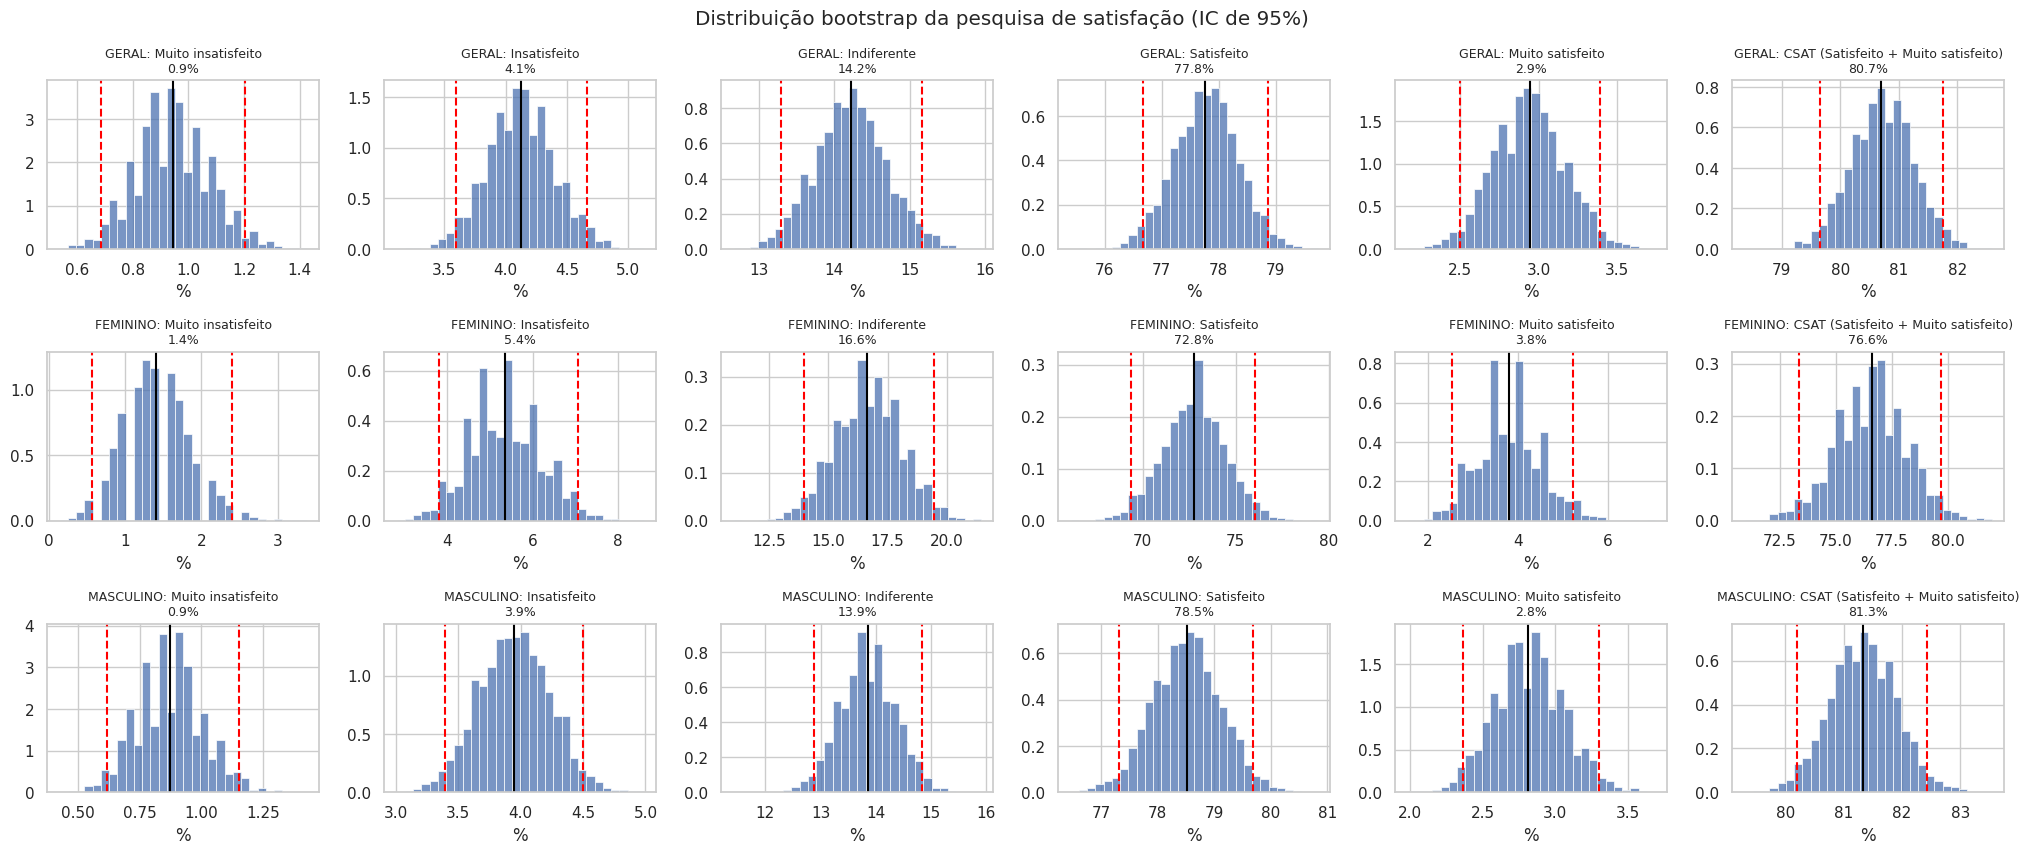

In [66]:
NIVEL_CSAT = "CSAT (Satisfeito + Muito satisfeito)"


def bootstrap_proporcao(indicador, nivel=0.95, repeticoes=5000, semente=42):
    """
    Estima uma proporção com intervalo de confiança e erro-padrão por bootstrap.

    Usa o intervalo percentil, que não depende do jackknife e roda bem em
    amostras grandes.

    Parâmetros
    ----------
    indicador : array-like
        Vetor de 0 e 1 (1 quando o cliente pertence ao nível analisado).
    nivel : float
        Nível de confiança do intervalo.
    repeticoes : int
        Número de reamostragens.
    semente : int
        Semente aleatória.

    Retorna
    -------
    dict
        Percentual (%), limites do intervalo (%), erro-padrão (pontos
        percentuais) e a distribuição bootstrap.
    """
    dados = (np.asarray(indicador, dtype=float),)

    # nível sem variação (0% ou 100%): não há o que reamostrar
    if np.unique(dados[0]).size == 1:
        p = 100 * float(dados[0][0])
        return {
            "Percentual (%)": p,
            "IC inferior (%)": p,
            "IC superior (%)": p,
            "Erro-padrão (p.p.)": 0.0,
            "distribuicao": np.full(repeticoes, dados[0][0]),
        }

    res = bootstrap(dados, np.mean, confidence_level=nivel, n_resamples=repeticoes,
                    method="percentile", random_state=np.random.default_rng(semente))
    return {
        "Percentual (%)": 100 * float(np.mean(dados[0])),
        "IC inferior (%)": 100 * float(res.confidence_interval.low),
        "IC superior (%)": 100 * float(res.confidence_interval.high),
        "Erro-padrão (p.p.)": 100 * float(res.standard_error),
        "distribuicao": res.bootstrap_distribution,
    }


def grafico_bootstrap_satisfacao(distribuicoes, recortes, niveis):
    """
    Desenha a distribuição bootstrap do percentual de cada nível em cada recorte.

    Parâmetros
    ----------
    distribuicoes : dict
        (recorte, nível) -> retorno de `bootstrap_proporcao`.
    recortes : list of str
        Linhas da figura (GERAL, FEMININO, MASCULINO).
    niveis : list of str
        Colunas da figura.
    """
    fig, eixos = plt.subplots(len(recortes), len(niveis),
                              figsize=(3.4 * len(niveis), 2.9 * len(recortes)))
    eixos = np.atleast_2d(eixos)

    for i, recorte in enumerate(recortes):
        for j, nivel in enumerate(niveis):
            res = distribuicoes[(recorte, nivel)]
            eixo = eixos[i, j]
            sns.histplot(100 * np.asarray(res["distribuicao"]), bins=30, stat="density", ax=eixo)
            eixo.axvline(res["IC inferior (%)"], color="red", linestyle="--")
            eixo.axvline(res["IC superior (%)"], color="red", linestyle="--")
            eixo.axvline(res["Percentual (%)"], color="black")
            eixo.set_title(f"{recorte}: {nivel}\n{res['Percentual (%)']:.1f}%", fontsize=9)
            eixo.set_xlabel("%")
            eixo.set_ylabel("")

    fig.suptitle("Distribuição bootstrap da pesquisa de satisfação (IC de 95%)")
    plt.tight_layout()
    plt.show()


def AtividadeA3_2(amostra, graficos=True):
    """
    HELP:
    Atividade A3.2: análise bootstrap do resultado da pesquisa de satisfação.

    Para o conjunto geral e para cada sexo, estima o percentual de cada nível
    da escala e do índice de satisfação (CSAT = Satisfeito + Muito satisfeito)
    com intervalo de confiança de 95% e erro-padrão por bootstrap.

    Parâmetros
    ----------
    amostra : pandas.DataFrame
        Amostra com a coluna SATISFAÇÃO.
    graficos : bool
        Se True desenha a distribuição bootstrap de cada estimativa.

    Retorna
    -------
    pandas.DataFrame
        Uma linha por recorte (GERAL, FEMININO, MASCULINO) e nível.
    """
    recortes = [("GERAL", amostra)] + [(s, d) for s, d in amostra.groupby("SEXO")]
    niveis = NIVEIS_SATISFACAO + [NIVEL_CSAT]
    linhas = []
    distribuicoes = {}

    for nome, dados in recortes:
        for nivel in niveis:
            if nivel == NIVEL_CSAT:
                indicador = dados["SATISFAÇÃO"].isin(["Satisfeito", "Muito satisfeito"]).astype(int)
            else:
                indicador = (dados["SATISFAÇÃO"] == nivel).astype(int)
            res = bootstrap_proporcao(indicador)
            distribuicoes[(nome, nivel)] = res
            linhas.append({
                "Recorte": nome,
                "Nível": nivel,
                "n": len(dados),
                **{k: v for k, v in res.items() if k != "distribuicao"},
            })

    resultado = pd.DataFrame(linhas).round(2)
    display(resultado)
    if graficos:
        grafico_bootstrap_satisfacao(distribuicoes, [nome for nome, _ in recortes], niveis)
    return resultado


resultado_a32 = AtividadeA3_2(amostra_ideal)

###Atividade A3.3: Resultado Final da Pesquisa de Satisfação

Recorte,GERAL,FEMININO,MASCULINO
Nível,,,
Muito insatisfeito,0.94,1.41,0.87
Insatisfeito,4.13,5.36,3.94
Indiferente,14.22,16.64,13.86
Satisfeito,77.76,72.78,78.51
Muito satisfeito,2.94,3.81,2.81
CSAT (Satisfeito + Muito satisfeito),80.70,76.59,81.33


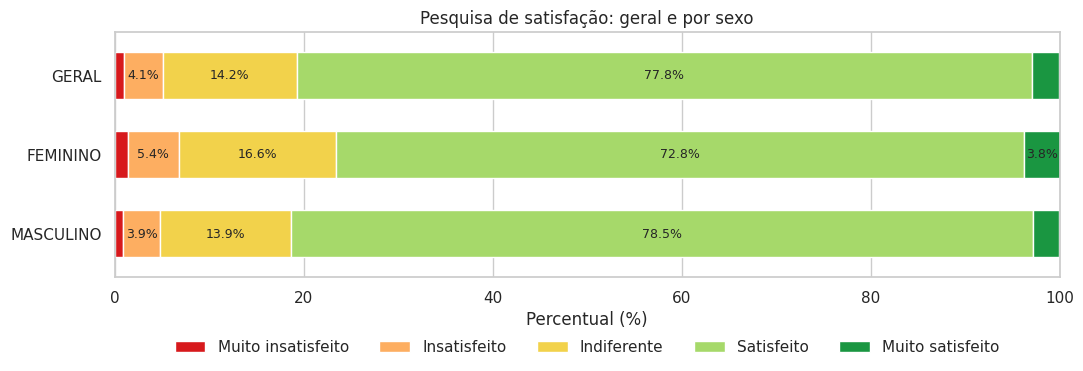

Qui-quadrado entre SEXO e CSAT: p-valor de 0.34%, logo a satisfação depende do sexo (nível de 5%).


In [67]:
CORES_SATISFACAO = ["#d7191c", "#fdae61", "#f2d24b", "#a6d96a", "#1a9641"]


def grafico_satisfacao(tabela):
    """
    Desenha barras 100% empilhadas da escala de satisfação para cada recorte.

    As cores seguem a escala do enunciado, do vermelho (Muito insatisfeito)
    ao verde (Muito satisfeito).

    Parâmetros
    ----------
    tabela : pandas.DataFrame
        Percentual de cada nível (linhas) por recorte (colunas).
    """
    dados = tabela.loc[NIVEIS_SATISFACAO].T
    eixo = dados.plot(kind="barh", stacked=True, color=CORES_SATISFACAO,
                      figsize=(11, 4), width=0.6)
    for barras in eixo.containers:
        rotulos = [f"{v:.1f}%" if v >= 3 else "" for v in barras.datavalues]
        eixo.bar_label(barras, labels=rotulos, label_type="center", fontsize=9)
    eixo.invert_yaxis()
    eixo.set_xlim(0, 100)
    eixo.set_xlabel("Percentual (%)")
    eixo.set_ylabel("")
    eixo.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=5, frameon=False)
    plt.title("Pesquisa de satisfação: geral e por sexo")
    plt.tight_layout()
    plt.show()


def AtividadeA3_3(resultado, amostra):
    """
    HELP:
    Atividade A3.3: resultado final da pesquisa de satisfação em %.

    Mostra o percentual de cada nível da escala e do CSAT no geral e por sexo,
    o gráfico de barras empilhadas e o teste qui-quadrado que verifica se o
    CSAT depende do sexo.

    Parâmetros
    ----------
    resultado : pandas.DataFrame
        Retorno da AtividadeA3_2.
    amostra : pandas.DataFrame
        Amostra com a coluna SATISFAÇÃO.

    Retorna
    -------
    dict
        tabela (percentual por nível e recorte) e p_sexo (p-valor do qui-quadrado).
    """
    recortes = ["GERAL"] + sorted(amostra["SEXO"].unique())
    tabela = resultado.pivot(index="Nível", columns="Recorte", values="Percentual (%)")
    tabela = tabela.loc[NIVEIS_SATISFACAO + [NIVEL_CSAT], recortes]
    display(tabela)
    grafico_satisfacao(tabela)

    satisfeito = amostra["SATISFAÇÃO"].isin(["Satisfeito", "Muito satisfeito"])
    p_sexo = stats.chi2_contingency(pd.crosstab(amostra["SEXO"], satisfeito))[1]
    decisao = "não depende" if p_sexo > 0.05 else "depende"
    print(f"Qui-quadrado entre SEXO e CSAT: p-valor de {100 * p_sexo:.2f}%, "
          f"logo a satisfação {decisao} do sexo (nível de 5%).")
    return {"tabela": tabela, "p_sexo": p_sexo}


resultado_a33 = AtividadeA3_3(resultado_a32, amostra_ideal)

**Resultado da pesquisa de satisfação**

Na escala de 5 níveis do enunciado, o resultado foi:

| Nível | Geral | Feminino | Masculino |
|---|---|---|---|
| Muito satisfeito | 2,9% | 3,8% | 2,8% |
| Satisfeito | 77,8% | 72,8% | 78,5% |
| Indiferente | 14,2% | 16,6% | 13,9% |
| Insatisfeito | 4,1% | 5,4% | 3,9% |
| Muito insatisfeito | 0,9% | 1,4% | 0,9% |
| **CSAT (Satisfeito + Muito satisfeito)** | **80,7%** | **76,6%** | **81,3%** |

O índice de satisfação (CSAT, soma de Satisfeito e Muito satisfeito) geral é de 80,7%, com intervalo de confiança de 95% de 79,7% a 81,8%. Entre as mulheres o CSAT é de 76,6% (IC de 73,3% a 79,7%) e entre os homens, de 81,3% (IC de 80,2% a 82,4%). O teste qui-quadrado entre sexo e CSAT deu p-valor de 0,34%, então a satisfação depende do sexo: as mulheres estão 4,7 pontos percentuais menos satisfeitas, com mais respostas indiferentes (16,6% contra 13,9%) e insatisfeitas (5,4% contra 3,9%).

A opinião do cliente foi convertida na escala com o seguinte critério: elogio enfático (excelente, perfeito, impecável, superou expectativas) é Muito satisfeito; elogio simples é Satisfeito; ausência de opinião é Indiferente; avaliação morna com ressalva (regular, comum, aceitável, esperava mais) é Insatisfeito; e reclamação direta (não gostei, atraso, falta de qualidade, experiência ruim, deixou a desejar) é Muito insatisfeito. A tabela da Atividade A3.1 mostra a classificação de cada frase, e todas as opiniões da amostra foram classificadas.

# RELATÓRIO FINAL - PARTE 1

Fazer aqui:

*   **RELATÓRIO FINAL - PARTE 1** com todas as conclusões e resultados que serão apresentados as gestores da **EMPRESA: UVVine**.
*   Responder a pergunta principal: **QUAL O TAMANHO IDEAL DA AMOSTRA ?**

Justifique sua resposta com os resultados obtidos:

    * Atividade A1: Estratificação amostral da população
    * Atividade A2: Estatística Descritiva

In [68]:
def RelatorioFinalParte1(res_a11, res_a12, normalidade, res_ind, res_dist, res_med,
                         amostra, res_a32, res_a33):
    """
    HELP:
    Relatório final da Parte 1: reúne os resultados das atividades A1, A2 e A3.

    Imprime, com os números desta execução, o tamanho ideal da amostra, o
    confronto com e sem outliers, as quatro características de SAMPLE 1 e
    SAMPLE 2 (normalidade, independência, distribuição e médias), a
    estatística descritiva e a pesquisa de satisfação.

    Parâmetros
    ----------
    res_a11, res_a12 : dict
        Retornos das Atividades A1.1 e A1.2.
    normalidade : pandas.DataFrame
        Resultado da Atividade A1.3.1.
    res_ind, res_dist, res_med : dict
        Retornos das Atividades A1.3.2, A1.3.3 e A1.3.4.
    amostra : pandas.DataFrame
        Amostra do tamanho ideal (com a coluna SATISFAÇÃO).
    res_a32 : pandas.DataFrame
        Retorno da Atividade A3.2.
    res_a33 : dict
        Retorno da Atividade A3.3.
    """
    limpa = res_a12["resultado"]
    n_bruta = res_a11["tabela"].set_index("Grupo")["n ideal (no grupo)"]
    n_limpa = limpa["tabela"].set_index("Grupo")["n ideal (no grupo)"]
    se_neyman = limpa["tabela"].set_index("Grupo").loc["NEYMAN (estratificado)", "SE no ponto (R$)"]
    outliers = res_a12["relatorio"].set_index("Estrato")

    print("1. Tamanho ideal da amostra")
    print(f"Tamanho ideal: {res_a12['n_ideal']} notas fiscais, o maior valor entre as duas rodadas.")
    print("Base bruta: " + ", ".join(f"{g} {int(v)}" for g, v in n_bruta.items()) + ".")
    print("Sem outliers: " + ", ".join(f"{g} {int(v)}" for g, v in n_limpa.items()) + ".")
    print(f"Sem outliers, a alocação de Neyman tem erro-padrão de R$ {se_neyman:.2f}, contra "
          f"R$ {limpa['se_simples']:.2f} de uma amostra aleatória simples do mesmo tamanho.")
    print(f"O tamanho ideal equivale a {res_a12['n_ideal'] / ENTRADA_DIARIA:.1f} dia(s) de entrada "
          f"de notas fiscais ({ENTRADA_DIARIA} por dia).")

    print()
    print("2. Outliers")
    por_estrato = ", ".join(
        f"{e} {int(outliers.loc[e, 'Outliers'])} ({outliers.loc[e, 'Outliers (%)']:.2f}%)"
        for e in outliers.index if e != "TOTAL"
    )
    print(f"{int(outliers.loc['TOTAL', 'Outliers'])} notas removidas "
          f"({outliers.loc['TOTAL', 'Outliers (%)']:.2f}%): {por_estrato}.")

    print()
    print(f"3. Características de SAMPLE 1 e SAMPLE 2 (n = {res_a12['n_ideal']} cada)")
    estratos = normalidade[normalidade["Grupo"] != "GERAL"]
    mais_proximo = estratos.groupby("Grupo")["AD estatística"].mean().idxmin()
    print(f"Normalidade (Anderson-Darling): {int(normalidade['Normal (5%)'].sum())} de "
          f"{len(normalidade)} casos não rejeitam a normalidade a 5%; estrato mais próximo "
          f"da normal: {mais_proximo}.")
    for nome, res in [("Independência", res_ind), ("Mesma distribuição", res_dist),
                      ("Médias iguais", res_med)]:
        m = res["melhor"]
        situacao = "confirmada" if res["mantida"] else "rejeitada"
        print(f"{nome}: {situacao}. Melhor ajuste {m['Teste']}, precisão de {m['Precisão (%)']:.1f}% "
              f"e p-valor de {m['p-valor SAMPLE 1 x 2 (%)']:.2f}% no par sorteado.")
    print(f"Médias: R$ {res_med['media_1']:.2f} (SAMPLE 1) e R$ {res_med['media_2']:.2f} (SAMPLE 2).")

    print()
    print("4. Estatística descritiva (amostra do tamanho ideal)")
    por_conta = amostra.groupby(ESTRATO)[ALVO].mean()
    print(f"Gasto médio de R$ {amostra[ALVO].mean():.2f} e mediana de R$ {amostra[ALVO].median():.2f}; "
          + "média por conta: " + ", ".join(f"{c} R$ {v:.2f}" for c, v in por_conta.items()) + ".")

    print()
    print("5. Pesquisa de satisfação")
    csat = res_a32[res_a32["Nível"] == NIVEL_CSAT].set_index("Recorte")
    for recorte, linha in csat.iterrows():
        print(f"CSAT {recorte}: {linha['Percentual (%)']:.1f}% (IC 95% de "
              f"{linha['IC inferior (%)']:.1f}% a {linha['IC superior (%)']:.1f}%).")
    print(f"Qui-quadrado entre sexo e CSAT: p-valor de {100 * res_a33['p_sexo']:.2f}%.")


RelatorioFinalParte1(resultado_a11, resultado_a12, normalidade, resultado_ind, resultado_dist,
                     resultado_med, amostra_ideal, resultado_a32, resultado_a33)

1. Tamanho ideal da amostra
Tamanho ideal: 5400 notas fiscais, o maior valor entre as duas rodadas.
Base bruta: ESSENTIAL 5300, PRIME 5300, VIP 5400, GERAL 5000, NEYMAN (estratificado) 5300.
Sem outliers: ESSENTIAL 5300, PRIME 5300, VIP 5200, GERAL 5400, NEYMAN (estratificado) 5300.
Sem outliers, a alocação de Neyman tem erro-padrão de R$ 4.39, contra R$ 11.07 de uma amostra aleatória simples do mesmo tamanho.
O tamanho ideal equivale a 1.1 dia(s) de entrada de notas fiscais (5000 por dia).

2. Outliers
12993 notas removidas (1.16%): ESSENTIAL 9889 (1.38%), PRIME 0 (0.00%), VIP 3104 (1.31%).

3. Características de SAMPLE 1 e SAMPLE 2 (n = 5400 cada)
Normalidade (Anderson-Darling): 0 de 8 casos não rejeitam a normalidade a 5%; estrato mais próximo da normal: PRIME.
Independência: confirmada. Melhor ajuste Qui-quadrado, precisão de 95.4% e p-valor de 35.68% no par sorteado.
Mesma distribuição: confirmada. Melhor ajuste Mann-Whitney, precisão de 96.1% e p-valor de 62.70% no par sorteado.


**Relatório final da Parte 1: tamanho ideal da amostra e perfil dos clientes da UVVine**

**Qual o tamanho ideal da amostra?**

O tamanho ideal é de **5.400 notas fiscais**. Ele foi obtido pela estabilização do erro-padrão médio do `TOTAL (R$)` em dois procedimentos: o empírico prático, com uma curva para cada grupo (ESSENTIAL, PRIME, VIP e GERAL), e o teórico, com a alocação de Neyman para a população estratificada. Pela regra do projeto foi adotado o maior valor encontrado, e as duas rodadas confrontadas chegaram a ele: 5.400 na base bruta (VIP) e 5.400 na base sem outliers (GERAL).

**Justificativa (Atividade A1: estratificação amostral da população)**

*   Todas as curvas estabilizam na mesma faixa (5.000 a 5.400 notas) porque o erro-padrão cai na proporção de 1/√n. Dobrar a amostra (limiar de 0,5%) reduziria o erro-padrão estratificado apenas de 5,32 reais para 3,81 reais, um ganho pequeno para o dobro do custo.
*   A estratificação por tipo de conta com alocação de Neyman reduz o erro-padrão de 11,07 reais (amostra aleatória simples do mesmo tamanho) para 4,39 reais na base sem outliers, 60,4% menor, porque os estratos têm níveis de gasto muito diferentes.
*   Foram removidos 12.993 outliers (1,16% das notas, todos no ESSENTIAL e no VIP), que formavam um grupo separado de gastos até cerca de 3.813 reais, típico de erro de registro. Sem eles, as médias deixaram de ser puxadas para cima e o tamanho ideal recalculado continuou em 5.400 notas.
*   Com o tamanho ideal, duas amostras sorteadas (SAMPLE 1 e SAMPLE 2) são independentes (qui-quadrado, precisão de 95,4%), têm a mesma distribuição (Mann-Whitney, precisão de 96,1%) e a mesma média (754,74 reais e 743,31 reais; t de Welch, precisão de 95,1%). A normalidade é rejeitada pelo Anderson-Darling nos 8 casos; o estrato mais próximo da normal é o PRIME.
*   O tamanho ideal equivale a pouco mais de um dia de entrada de notas fiscais (cerca de 5.000 por dia) e representa só 0,48% da base atual. A correção para população finita mudaria o erro-padrão em apenas 0,24%, o que confirma a hipótese de população infinita e permite renovar a amostra diariamente.

**Estatística descritiva (Atividade A2)**

*   Gasto médio de 754,74 reais por nota (mediana de 472,38 reais), crescendo com o tipo de conta: 362,39 reais no ESSENTIAL, 875,60 reais no VIP e 2.271,83 reais no PRIME.
*   A renda bruta separa claramente os três tipos de conta (médias de 3.284 reais, 7.933 reais e 20.635 reais) e deve ser a principal variável explicativa da Parte 2. Sexo, estado civil e região quase não alteram o gasto.
*   Pontos de atenção para a Parte 2: 7 das 13 variáveis do vinho têm valores negativos, e a NOTA DE SATISFAÇÃO só varia entre os clientes PRIME.

**Pesquisa de satisfação (Atividade A3)**

*   80,7% dos clientes estão satisfeitos ou muito satisfeitos (IC 95% de 79,7% a 81,8%), com diferença significativa entre os sexos: 76,6% entre as mulheres e 81,3% entre os homens (qui-quadrado, p-valor de 0,34%). As mulheres concentram mais respostas indiferentes e insatisfeitas, o que indica um ponto de atenção para a UVVine.
*   Apenas 5,1% dos clientes estão insatisfeitos ou muito insatisfeitos; as reclamações diretas citam atraso na entrega, falta de qualidade e atendimento.

In [1]:
%%shell

jupyter nbconvert --to html /content/ARIDALTON_JUNIOR.ipynb

[NbConvertApp] Converting notebook /content/ARIDALTON_JUNIOR.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 26 image(s).
[NbConvertApp] Writing 4642461 bytes to /content/ARIDALTON_JUNIOR.html
